# Sentiment Analysis and Topic Modeling of US Presidential Debates from 1960 to 2024

### Daniel Henke (176182), Sven Kurth (175866), Margherita Grosso (176786), Luca Gudi (175880)

## Install and Load Packages

In [38]:
%pip install -q numpy scipy pandas matplotlib seaborn wordcloud
%pip install -q nltk spacy transformers torch wordcloud gensim
%pip install -q scikit-learn umap-learn hdbscan
%pip install -q bertopic keybert sentence-transformers
%pip install -q tensorflow==2.16.1 tf-keras
%pip install -q hf_xet ipywidgets tqdm

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)



[notice] A new release of pip is available: 24.2 -> 25.1.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)



[notice] A new release of pip is available: 24.2 -> 25.1.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


...


[notice] A new release of pip is available: 24.2 -> 25.1.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)



[notice] A new release of pip is available: 24.2 -> 25.1.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)



[notice] A new release of pip is available: 24.2 -> 25.1.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [1]:
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('vader_lexicon')

import spacy
try:
    nlp = spacy.load("en_core_web_sm")
except OSError:
    from spacy.cli import download
    download("en_core_web_sm")
    nlp = spacy.load("en_core_web_sm")

[nltk_data] Error loading punkt: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1000)>
[nltk_data] Error loading stopwords: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1000)>
[nltk_data] Error loading wordnet: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1000)>
[nltk_data] Error loading vader_lexicon: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1000)>


In [2]:
import os
import re
import json
import numpy as np
import pandas as pd
from collections import Counter, defaultdict
from tqdm import tqdm
tqdm.pandas()  # Adds a progress_apply method to pandas objects
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib import cm
import seaborn as sns
from wordcloud import WordCloud

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, TreebankWordTokenizer
from nltk.stem import WordNetLemmatizer, SnowballStemmer, PorterStemmer
from nltk.sentiment import SentimentIntensityAnalyzer

import spacy
nlp = spacy.load("en_core_web_sm")

import torch
from scipy.special import softmax

from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification, AutoConfig
)

from transformers.pipelines import pipeline


from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sentence_transformers import SentenceTransformer

# Topic modeling
from bertopic import BERTopic
from keybert import KeyBERT

# Gensim
import gensim
from gensim.utils import simple_preprocess
from gensim.parsing.preprocessing import STOPWORDS
from gensim import corpora
from gensim.models import LdaModel, CoherenceModel, LdaSeqModel

import hf_xet

# Load and Prepare Data

## Create Dataframe for US Debates from 1960 to 2020 the Dataset from Kaggle

### Define Directory

In [3]:
DATA_DIRECTORY = "data_dir"

### Meta Data

In [4]:
INCUMBENT_PAIRS = {
    ("ford", "1976"), ("carter", "1980"), ("reagan", "1984"), ("bush", "1984"),
    ("bush", "1992"), ("quayle", "1992"), ("clinton", "1996"), ("gore", "1996"),
    ("bush", "2004"), ("cheney", "2004"), ("obama", "2012"), ("biden", "2012"),
    ("trump", "2020"), ("pence", "2020")
}

WINNER_PAIRS = {
    ("kennedy", "1960"), ("carter", "1976"), ("reagan", "1980"), ("bush", "1980"),
    ("reagan", "1984"), ("bush", "1984"), ("bush", "1988"), ("quayle", "1988"),
    ("clinton", "1992"), ("gore", "1992"), ("clinton", "1996"), ("gore", "1996"),
    ("bush", "2000"), ("cheney", "2000"), ("bush", "2004"), ("cheney", "2004"),
    ("obama", "2008"), ("biden", "2008"), ("obama", "2012"), ("biden", "2012"),
    ("trump", "2016"), ("pence", "2016"), ("biden", "2020"), ("harris", "2020")
}

CANDIDATES = {
    # Presidential
    "kennedy": "Democratic", "nixon": "Republican", "ford": "Republican",
    "carter": "Democratic", "reagan": "Republican", "anderson": "Independent",
    "mondale": "Democratic", "bush": "Republican", "dukakis": "Democratic",
    "clinton": "Democratic", "perot": "Independent", "dole": "Republican",
    "gore": "Democratic", "kerry": "Democratic", "obama": "Democratic",
    "mccain": "Republican", "romney": "Republican", "trump": "Republican",
    "biden": "Democratic",

    # Vice-Presidential
    "ferraro": "Democratic", "quayle": "Republican", "bentsen": "Democratic",
    "kemp": "Republican", "stockdale": "Independent", "lieberman": "Democratic", "cheney": "Republican",
    "edwards": "Democratic", "palin": "Republican", "ryan": "Republican",
    "kaine": "Democratic", "pence": "Republican", "harris": "Democratic",
    "vance": "Republican"
}

CANDIDATE_FIRST_NAMES = {"Kennedy": "John","Humphrey": "Hubert","McGovern": "George","Carter": "Jimmy","Mondale": "Walter",
    "Dukakis": "Michael", "Clinton Bill": "Bill", "Gore": "Al", "Kerry": "John", "Obama": "Barack", "Clinton Hillary": "Hillary",
    "Biden": "Joe","Nixon": "Richard","Goldwater": "Barry","Ford": "Gerald","Reagan": "Ronald","Bush Sr": "George",  
    "Bush Jr": "George","Dole": "Bob","Mccain": "John","Romney": "Mitt","Trump": "Donald","Kemp": "Jack","Perot": "Ross",
    "Anderson": "John","Ferraro": "Geraldine","Quayle": "Dan","Lieberman": "Joe","Edwards": "John","Palin": "Sarah",
    "Ryan": "Paul","Pence": "Mike","Harris": "Kamala","Cheney": "Dick","Bentsen": "Lloyd","Kaine": "Tim","Stockdale": "James",
    "Walz": "Tim","Vance": "J.D."
}

VP_CORRECTIONS = ["2000-10-11", "2008-09-26", "2012-10-03"]

### Functions for Data Cleaning

In [5]:
def normalize_last_name(full_name):
    """Extracts the last name and applies capitalization."""
    if not full_name or full_name == "UNKNOWN":
        return "UNKNOWN"
    return full_name.strip().split()[-1].capitalize()

def fix_duplicate_names(last_name, year, is_candidate, party):
    """Fixes duplicate names for specific cases."""
    if last_name.lower() == "bush":
        last_name = "Bush Sr" if str(year) in ["1984", "1988", "1992"] else "Bush Jr"
    elif last_name.lower() == "clinton":
        last_name = "Clinton Hillary" if str(year) == "2016" else "Clinton Bill"
    elif last_name.lower() == "edwards" and str(year) == "1960":
        is_candidate = False
        party = None
    return last_name, is_candidate, party

### Functions for Data Enrichment

In [6]:
def check_incumbent(last_name, year):
    """Returns True if candidate is incumbent that year."""
    return (last_name.lower(), str(year)) in INCUMBENT_PAIRS

def check_winner(last_name, year):
    """Returns True if candidate won in that year."""
    return (last_name.lower(), str(year)) in WINNER_PAIRS

def check_candidate(last_name):
    """Returns whether person was a candidate and their party if applicable."""
    key = last_name.lower()
    return (key in CANDIDATES), CANDIDATES.get(key)

def is_vp_debate(content):
    """Determines if a debate is a Vice-Presidential debate."""
    dialogues = [entry.get("dialogue", "").lower() for entry in content[:5]]
    return any("vice presidential" in d for d in dialogues)

def correct_vp_debate_flags(df):
    """Manually corrects VP debate flags for known false positives."""
    for d in VP_CORRECTIONS:
        df.loc[df["date"] == pd.to_datetime(d).date(), "VP_debate"] = False
    return df

def parse_date(date_list):
    """Converts a date list into a datetime.date object or returns 'UNKNOWN'."""
    try:
        return pd.to_datetime(" ".join(date_list)).date()
    except Exception:
        return pd.NaT

def add_first_name(df, actor_column="actor", new_column="first_name", name_dict=None):
    """Adds a column with first names to a DataFrame by mapping values from an actor column."""
    if name_dict is None:
        name_dict = CANDIDATE_FIRST_NAMES
    df[new_column] = df[actor_column].map(name_dict)
    return df

def generate_debate_titles(df):
    """Add a 'debate_title' column to the DataFrame."""
    debate_titles = {}
    debate_counter = defaultdict(Counter)

    for date, group in df.groupby("date"):
        year = group["year"].iloc[0]
        is_vp = group["VP_debate"].iloc[0]
        
        # Get sorted unique candidate last names
        candidate_names = sorted(set(group[group["is_candidate"]]["actor"]))
        title_base = f"{year}_" + "_".join(candidate_names)

        if is_vp:
            full_title = f"{title_base}_VP"
        else:
            # Number the debate among similar candidate sets in same year
            debate_counter[year][title_base] += 1
            count = debate_counter[year][title_base]
            full_title = f"{title_base}_{count}"

        debate_titles[date] = full_title

    df["debate_title"] = df["date"].map(debate_titles)
    return df

### Functions for Loading Data from Directory

In [7]:
def get_json_files(directory):
    """Retrieves JSON files excluding partials from a directory."""
    return [
        os.path.join(directory, f)
        for f in os.listdir(directory)
        if f.endswith(".json") and not f.startswith("part")
    ]


### Final Pipeline Functions for Data Loading and Dataframe Creation

In [8]:
def process_debate_file(file_path):
    """Processes a single JSON debate file and returns a list of parsed rows."""
    rows = []
    with open(file_path, "r", encoding="utf-8") as f:
        debate = json.load(f)
        content = debate.get("content", [])
        date = parse_date(debate.get("date", []))
        year = date.year if pd.notnull(date) else "UNKNOWN"
        vp_flag = is_vp_debate(content)

        for entry in content:
            actor_raw = entry.get("actor", "UNKNOWN")
            dialogue = entry.get("dialogue", "")
            last_name = normalize_last_name(actor_raw)

            is_candidate, party = check_candidate(last_name)
            is_incumbent = check_incumbent(last_name, year)
            is_winner = check_winner(last_name, year)

            # Fix duplicate names and candidate status
            last_name, is_candidate, party = fix_duplicate_names(last_name, year, is_candidate, party)
            first_name = CANDIDATE_FIRST_NAMES.get(last_name)

            rows.append({
                "debate_title" : None,
                "date": date,
                "year": year,
                "actor": last_name,
                "first_name": first_name,
                "dialogue": dialogue,
                "is_candidate": is_candidate,
                "party": party,
                "is_winner": is_winner,
                "VP_debate": vp_flag,
                "is_incumbent": is_incumbent
            })
    return rows
    
def debates_to_dataframe(directory):
    """Converts debate JSON files to a DataFrame."""
    
    all_rows = []
    json_files = get_json_files(directory)

    for file_path in json_files:
        all_rows.extend(process_debate_file(file_path))

    df = pd.DataFrame(all_rows)
    df = correct_vp_debate_flags(df)
    df = generate_debate_titles(df)
    return df

In [9]:
df_debates=debates_to_dataframe(DATA_DIRECTORY)
df_debates.head()

,debate_title,date,year,actor,first_name,dialogue,is_candidate,party,is_winner,VP_debate,is_incumbent
0,2020_Biden_Trump_1,2020-09-29,2020,Participants,None,Former Vice President Joe Biden (D) and,False,None,False,False,False
1,2020_Biden_Trump_1,2020-09-29,2020,Moderator,None,Chris Wallace (Fox News),False,None,False,False,False
2,2020_Biden_Trump_1,2020-09-29,2020,Wallace,None,Good evening from the Health Education Campus ...,False,None,False,False,False
3,2020_Biden_Trump_1,2020-09-29,2020,Biden,Joe,"How you doing, man?",True,Democratic,True,False,False
4,2020_Biden_Trump_1,2020-09-29,2020,Trump,Donald,How are you doing?,True,Republican,False,False,True


## Add 1992 and 2024 Debates from txt.files to Dataframe

### Function for Loading txt.files from Directory with Data Enrichment

We rely on pattern matching to separate the speakers and each statement

In [10]:
def extract_debate_txt(file_path, title, year, date, vp_debate, candidate_info):
    """Extracts structured debate data from a transcript text file.
    Args:
        file_path (str): Path to the transcript text file.
        title (str): Title of the debate.
        year (int): Year of the debate.
        date (str): Date of the debate in 'YYYY-MM-DD' format.
        vp_debate (bool): Whether this is a vice-presidential debate.
        candidate_info (dict): Dictionary mapping speaker last names to:
            {"is_candidate": bool, "party": str, "is_winner": bool, "is_incumbent": bool}
    """
    with open(file_path, 'r', encoding='utf-8') as f:
        lines = [line.strip() for line in f if line.strip()]

    date = pd.to_datetime(date, errors="coerce").date() if date else None
    pattern = re.compile(r'^([A-Z][A-Z\s.\-]*)(?:, [A-Z\s.]+)?:\s*(.*)')

    data, current_actor, current_text = [], None, []

    def append_block(actor, text):
        if not actor or not text:
            return
    
        actor = actor.title()  # normalize
        info = candidate_info.get(actor, {
            'is_candidate': False,
            'party': None,
            'is_winner': False,
            'is_incumbent': False
        })
    
        first_name = CANDIDATE_FIRST_NAMES.get(actor)
    
        data.append({
            "debate_title": title,
            "date": date,
            "year": year,
            "actor": actor,
            "first_name": first_name,
            "dialogue": ' '.join(text).strip(),
            "is_candidate": info['is_candidate'],
            "party": info['party'],
            "is_winner": info['is_winner'],
            "VP_debate": vp_debate,
            "is_incumbent": info['is_incumbent']
        })
    

    for line in lines:
        match = pattern.match(line)
        if match:
            append_block(current_actor, current_text)
            current_actor = match.group(1).split()[-1].title()
            current_text = [match.group(2)] if match.group(2) else []
        else:
            current_text.append(line)

    append_block(current_actor, current_text)
    return pd.DataFrame(data)

### Complete and Enrich 1992 debate

In [11]:
debate_1992_first_half=extract_debate_txt(
    file_path="data_dir/transcript_1992_oct_15_first_half.txt",
    title="1992_Bush Sr_Clinton Bill_Perot_2",
    year=1992, date="1992-10-15", vp_debate=False,
    candidate_info={
        "Bush": {"is_candidate": True, "party": "Republican","is_winner": False,"is_incumbent": True},
        "Clinton": {"is_candidate": True,"party": "Democratic","is_winner": True,"is_incumbent": False},
        "Perot": {"is_candidate": True,"party": "Independent","is_winner": False,"is_incumbent": False}
    }
)

#Rename Bush to Bush Sr and Clinton to Clinton (Bill)
debate_1992_first_half.loc[debate_1992_first_half["actor"] == "Bush", "actor"] = "Bush Sr"
debate_1992_first_half.loc[debate_1992_first_half["actor"] == "Clinton", "actor"] = "Clinton Bill"

#Assign first names
debate_1992_first_half = add_first_name(debate_1992_first_half, actor_column="actor", new_column="first_name")

debate_1992_first_half.head(20)

,debate_title,date,year,actor,first_name,dialogue,is_candidate,party,is_winner,VP_debate,is_incumbent
0,1992_Bush Sr_Clinton Bill_Perot_2,1992-10-15,1992,Simpson,NaN,Good evening and welcome to this second of thr...,False,None,False,False,False
1,1992_Bush Sr_Clinton Bill_Perot_2,1992-10-15,1992,Bush Sr,George,Let’s go.,True,Republican,False,False,True
2,1992_Bush Sr_Clinton Bill_Perot_2,1992-10-15,1992,Simpson,NaN,And I think the first question is over here.,False,None,False,False,False
3,1992_Bush Sr_Clinton Bill_Perot_2,1992-10-15,1992,Question,NaN,Yes. I’d like to direct my question to Mr. Per...,False,None,False,False,False
4,1992_Bush Sr_Clinton Bill_Perot_2,1992-10-15,1992,Perot,Ross,That’s right at the top of my agenda. We’ve sh...,True,Independent,False,False,False
5,1992_Bush Sr_Clinton Bill_Perot_2,1992-10-15,1992,Simpson,NaN,"Thank you, Mr. Perot. I see that the president...",False,None,False,False,False
6,1992_Bush Sr_Clinton Bill_Perot_2,1992-10-15,1992,Bush Sr,George,"Carole, the thing that saved us in this global...",True,Republican,False,False,True
7,1992_Bush Sr_Clinton Bill_Perot_2,1992-10-15,1992,Simpson,NaN,Governor Clinton.,False,None,False,False,False
8,1992_Bush Sr_Clinton Bill_Perot_2,1992-10-15,1992,Clinton Bill,Bill,"I’d like to answer the question, because I’ve ...",True,Democratic,True,False,False
9,1992_Bush Sr_Clinton Bill_Perot_2,1992-10-15,1992,Simpson,NaN,Thank you. I think we have a question over here.,False,None,False,False,False


In [12]:
#concat with the rest of the data
df_debates = pd.concat([ debate_1992_first_half, df_debates], ignore_index=True)
df_debates.head(20)

,debate_title,date,year,actor,first_name,dialogue,is_candidate,party,is_winner,VP_debate,is_incumbent
0,1992_Bush Sr_Clinton Bill_Perot_2,1992-10-15,1992,Simpson,NaN,Good evening and welcome to this second of thr...,False,None,False,False,False
1,1992_Bush Sr_Clinton Bill_Perot_2,1992-10-15,1992,Bush Sr,George,Let’s go.,True,Republican,False,False,True
2,1992_Bush Sr_Clinton Bill_Perot_2,1992-10-15,1992,Simpson,NaN,And I think the first question is over here.,False,None,False,False,False
3,1992_Bush Sr_Clinton Bill_Perot_2,1992-10-15,1992,Question,NaN,Yes. I’d like to direct my question to Mr. Per...,False,None,False,False,False
4,1992_Bush Sr_Clinton Bill_Perot_2,1992-10-15,1992,Perot,Ross,That’s right at the top of my agenda. We’ve sh...,True,Independent,False,False,False
5,1992_Bush Sr_Clinton Bill_Perot_2,1992-10-15,1992,Simpson,NaN,"Thank you, Mr. Perot. I see that the president...",False,None,False,False,False
6,1992_Bush Sr_Clinton Bill_Perot_2,1992-10-15,1992,Bush Sr,George,"Carole, the thing that saved us in this global...",True,Republican,False,False,True
7,1992_Bush Sr_Clinton Bill_Perot_2,1992-10-15,1992,Simpson,NaN,Governor Clinton.,False,None,False,False,False
8,1992_Bush Sr_Clinton Bill_Perot_2,1992-10-15,1992,Clinton Bill,Bill,"I’d like to answer the question, because I’ve ...",True,Democratic,True,False,False
9,1992_Bush Sr_Clinton Bill_Perot_2,1992-10-15,1992,Simpson,NaN,Thank you. I think we have a question over here.,False,None,False,False,False


### Add and Enrich 2024 Debates

In [13]:
debate_2024_biden=extract_debate_txt(
    file_path="data_dir/transcript_2024_Trump_Biden.txt",
    title="2024_Trump_Biden",
    year=2024,date="2024-07-27",vp_debate=False,
    candidate_info={
        "Trump": {"is_candidate": True,"party": "Republican","is_winner": True,"is_incumbent": False},
        "Biden": {"is_candidate": True,"party": "Democratic","is_winner": False,"is_incumbent": True}
    }
)

df_debates = pd.concat([df_debates, debate_2024_biden], ignore_index=True)
debate_2024_biden.head(20)

,debate_title,date,year,actor,first_name,dialogue,is_candidate,party,is_winner,VP_debate,is_incumbent
0,2024_Trump_Biden,2024-07-27,2024,Tapper,None,"We’re live from Georgia, a key battleground st...",False,None,False,False,False
1,2024_Trump_Biden,2024-07-27,2024,Bash,None,This debate is being produced by CNN and it’s ...,False,None,False,False,False
2,2024_Trump_Biden,2024-07-27,2024,Tapper,None,"I’m Jake Tapper, anchor of CNN’s “The Lead” an...",False,None,False,False,False
3,2024_Trump_Biden,2024-07-27,2024,Bash,None,"When it’s time for a candidate to speak, his m...",False,None,False,False,False
4,2024_Trump_Biden,2024-07-27,2024,Tapper,None,Now please welcome the 46th president of the U...,False,None,False,False,False
5,2024_Trump_Biden,2024-07-27,2024,Biden,Joe,How are you? Good to be here. Thank you.,True,Democratic,False,False,True
6,2024_Trump_Biden,2024-07-27,2024,Tapper,None,And please welcome the 45th president of the U...,False,None,False,False,False
7,2024_Trump_Biden,2024-07-27,2024,Biden,Joe,You have to take a look at what I was left whe...,True,Democratic,False,False,True
8,2024_Trump_Biden,2024-07-27,2024,Tapper,None,Thank you. President Trump?,False,None,False,False,False
9,2024_Trump_Biden,2024-07-27,2024,Trump,Donald,We had the greatest economy in the history of ...,True,Republican,True,False,False


In [14]:
debate_2024_harris=extract_debate_txt(
    file_path="data_dir/transcript_2024_Trump_Harris.txt",
    title="2024_Trump_Harris",
    year=2024,date="2024-09-10",vp_debate=False,
    candidate_info={
        "Trump": {"is_candidate": True,"party": "Republican","is_winner": True,"is_incumbent": False},
        "Harris": {"is_candidate": True,"party": "Democratic","is_winner": False,"is_incumbent": False}
    }
)

df_debates = pd.concat([df_debates, debate_2024_harris], ignore_index=True)

debate_2024_harris.head(20)

,debate_title,date,year,actor,first_name,dialogue,is_candidate,party,is_winner,VP_debate,is_incumbent
0,2024_Trump_Harris,2024-09-10,2024,Muir,None,"Tonight, the high-stakes showdown here in Phil...",False,None,False,False,False
1,2024_Trump_Harris,2024-09-10,2024,Davis,None,A historic race for president upended just wee...,False,None,False,False,False
2,2024_Trump_Harris,2024-09-10,2024,Muir,None,The candidates separated by the smallest of ma...,False,None,False,False,False
3,2024_Trump_Harris,2024-09-10,2024,Muir,None,"Good evening, I'm David Muir. And thank you fo...",False,None,False,False,False
4,2024_Trump_Harris,2024-09-10,2024,Davis,None,And I'm Linsey Davis. Tonight's meeting could ...,False,None,False,False,False
5,2024_Trump_Harris,2024-09-10,2024,Muir,None,And that brings us to the rules of tonight's d...,False,None,False,False,False
6,2024_Trump_Harris,2024-09-10,2024,Davis,None,President Trump won the coin toss. He chose to...,False,None,False,False,False
7,2024_Trump_Harris,2024-09-10,2024,Muir,None,So let's now welcome the candidates to the sta...,False,None,False,False,False
8,2024_Trump_Harris,2024-09-10,2024,Harris,Kamala,Kamala Harris. Let's have a good debate.,True,Democratic,False,False,False
9,2024_Trump_Harris,2024-09-10,2024,Trump,Donald,Nice to see you. Have fun.,True,Republican,True,False,False


In [15]:
debate_2024_vp=extract_debate_txt(
    file_path="data_dir/transcript_2024_Vance_Walz.txt",
    title="2024_Vance_Walz_VP",
    year=2024,date="2024-10-01",vp_debate=True,
    candidate_info={
        "Jdv": {"is_candidate": True,"party": "Republican","is_winner": True,"is_incumbent": False},
        "Tw": {"is_candidate": True,"party": "Democratic","is_winner": False,"is_incumbent": False}
    }
)

#Rename Jdv to Vance, Tw to Walz, No to O'Donnell, and Mb to Brennan
debate_2024_vp.loc[debate_2024_vp["actor"] == "Jdv", "actor"] = "Vance"
debate_2024_vp.loc[debate_2024_vp["actor"] == "Tw", "actor"] = "Walz"
debate_2024_vp.loc[debate_2024_vp["actor"] == "No", "actor"] = "O'Donnell"
debate_2024_vp.loc[debate_2024_vp["actor"] == "Mb", "actor"] = "Brennan"

#Assign first names
debate_2024_vp = add_first_name(debate_2024_vp, actor_column="actor", new_column="first_name")

df_debates = pd.concat([df_debates, debate_2024_vp], ignore_index=True)
debate_2024_vp.head(20)

,debate_title,date,year,actor,first_name,dialogue,is_candidate,party,is_winner,VP_debate,is_incumbent
0,2024_Vance_Walz_VP,2024-10-01,2024,O'Donnell,NaN,Good evening. I'm Norah O'Donnell and thank yo...,False,None,False,True,False
1,2024_Vance_Walz_VP,2024-10-01,2024,Brennan,NaN,I'm Margaret Brennan. In order to have a thoug...,False,None,False,True,False
2,2024_Vance_Walz_VP,2024-10-01,2024,Brennan,NaN,"Thank you, Norah. Earlier today, Iran launched...",False,None,False,True,False
3,2024_Vance_Walz_VP,2024-10-01,2024,Walz,Tim,"Well, thank you. And thank you for those joini...",True,Democratic,False,True,False
4,2024_Vance_Walz_VP,2024-10-01,2024,Brennan,NaN,"Governor, your time is up. Senator Vance, the ...",False,None,False,True,False
5,2024_Vance_Walz_VP,2024-10-01,2024,Vance,J.D.,"So, Margaret, I want to answer the question. F...",True,Republican,True,True,False
6,2024_Vance_Walz_VP,2024-10-01,2024,Brennan,NaN,"Thank you, Senator. Governor Walz, do you care...",False,None,False,True,False
7,2024_Vance_Walz_VP,2024-10-01,2024,Walz,Tim,"Well, look, Donald Trump was in office. We'll ...",True,Democratic,False,True,False
8,2024_Vance_Walz_VP,2024-10-01,2024,Brennan,NaN,"Senator Vance, the U.S. did have a diplomatic ...",False,None,False,True,False
9,2024_Vance_Walz_VP,2024-10-01,2024,Vance,J.D.,"Well, first of all, Margaret, diplomacy is not...",True,Republican,True,True,False


### Sort Rows based on Year & Add Word Count

In [16]:
df_debates.sort_values(by=["year", "date"], inplace=True)
df_debates.reset_index(drop=True, inplace=True)
df_debates['word_count'] = df_debates['dialogue'].apply(lambda x: len(str(x).split()))
df_debates

,debate_title,date,year,actor,first_name,dialogue,is_candidate,party,is_winner,VP_debate,is_incumbent,word_count
0,1960_Kennedy_Nixon_1,1960-09-26,1960,Kennedy,John,"Mr. Smith, Mr. Nixon. In the election of 1860,...",True,Democratic,True,False,False,1249
1,1960_Kennedy_Nixon_1,1960-09-26,1960,Smith,None,And now the opening statement by Vice Presiden...,False,None,False,False,False,11
2,1960_Kennedy_Nixon_1,1960-09-26,1960,Nixon,Richard,"Mr. Smith, Senator Kennedy. The things that Se...",True,Republican,False,False,False,1382
3,1960_Kennedy_Nixon_1,1960-09-26,1960,Smith,None,"Thank you, Mr. Nixon. That completes the openi...",False,None,False,False,False,62
4,1960_Kennedy_Nixon_1,1960-09-26,1960,Fleming,None,"Senator, the Vice President in his campaign ha...",False,None,False,False,False,41
...,...,...,...,...,...,...,...,...,...,...,...,...
9928,2024_Vance_Walz_VP,2024-10-01,2024,Walz,Tim,"Well, thank you, Senator Vance. Thank you to C...",True,Democratic,False,True,False,391
9929,2024_Vance_Walz_VP,2024-10-01,2024,Brennan,NaN,"Governor Walz. Thank you. Senator Vance, your ...",False,None,False,True,False,9
9930,2024_Vance_Walz_VP,2024-10-01,2024,Vance,J.D.,"Well, I want to thank Governor Walz, you folks...",True,Republican,True,True,False,452
9931,2024_Vance_Walz_VP,2024-10-01,2024,Brennan,NaN,"Senator Vance, thank you. And thank you both f...",False,None,False,True,False,23


### Save as CSV

In [17]:
# Save the final DataFrame to a CSV file
df_debates.to_csv("df_transcripts.csv", index=False, encoding="utf-8")
print(f"Data saved")

Data saved


# Exploratory Data Analysis

### Read CSV

In [18]:
df_transcripts = pd.read_csv('df_transcripts.csv')
df_candidates = df_transcripts[df_transcripts['is_candidate'] == True].copy()


In [19]:
df_transcripts

,debate_title,date,year,actor,first_name,dialogue,is_candidate,party,is_winner,VP_debate,is_incumbent,word_count
0,1960_Kennedy_Nixon_1,1960-09-26,1960,Kennedy,John,"Mr. Smith, Mr. Nixon. In the election of 1860,...",True,Democratic,True,False,False,1249
1,1960_Kennedy_Nixon_1,1960-09-26,1960,Smith,NaN,And now the opening statement by Vice Presiden...,False,NaN,False,False,False,11
2,1960_Kennedy_Nixon_1,1960-09-26,1960,Nixon,Richard,"Mr. Smith, Senator Kennedy. The things that Se...",True,Republican,False,False,False,1382
3,1960_Kennedy_Nixon_1,1960-09-26,1960,Smith,NaN,"Thank you, Mr. Nixon. That completes the openi...",False,NaN,False,False,False,62
4,1960_Kennedy_Nixon_1,1960-09-26,1960,Fleming,NaN,"Senator, the Vice President in his campaign ha...",False,NaN,False,False,False,41
...,...,...,...,...,...,...,...,...,...,...,...,...
9928,2024_Vance_Walz_VP,2024-10-01,2024,Walz,Tim,"Well, thank you, Senator Vance. Thank you to C...",True,Democratic,False,True,False,391
9929,2024_Vance_Walz_VP,2024-10-01,2024,Brennan,NaN,"Governor Walz. Thank you. Senator Vance, your ...",False,NaN,False,True,False,9
9930,2024_Vance_Walz_VP,2024-10-01,2024,Vance,J.D.,"Well, I want to thank Governor Walz, you folks...",True,Republican,True,True,False,452
9931,2024_Vance_Walz_VP,2024-10-01,2024,Brennan,NaN,"Senator Vance, thank you. And thank you both f...",False,NaN,False,True,False,23


In [20]:
df_transcripts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9933 entries, 0 to 9932
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   debate_title  9933 non-null   object
 1   date          9933 non-null   object
 2   year          9933 non-null   int64 
 3   actor         9933 non-null   object
 4   first_name    5653 non-null   object
 5   dialogue      9933 non-null   object
 6   is_candidate  9933 non-null   bool  
 7   party         5651 non-null   object
 8   is_winner     9933 non-null   bool  
 9   VP_debate     9933 non-null   bool  
 10  is_incumbent  9933 non-null   bool  
 11  word_count    9933 non-null   int64 
dtypes: bool(4), int64(2), object(6)
memory usage: 659.7+ KB


In [21]:
df_transcripts.describe(include="all")

,debate_title,date,year,actor,first_name,dialogue,is_candidate,party,is_winner,VP_debate,is_incumbent,word_count
count,9933,9933,9933.000000,9933,5653,9933,9933,5651,9933,9933,9933,9933.000000
unique,48,48,NaN,171,29,8563,2,3,2,2,2,NaN
top,2020_Biden_Trump_1,2020-09-29,NaN,Trump,Donald,(CROSSTALK),True,Republican,False,False,False,NaN
freq,858,858,NaN,930,930,163,5651,2990,7187,7334,8332,NaN
mean,NaN,NaN,2004.906876,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,74.336756
std,NaN,NaN,14.783792,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,114.001134
min,NaN,NaN,1960.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000
25%,NaN,NaN,1992.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.000000
50%,NaN,NaN,2008.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.000000
75%,NaN,NaN,2016.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,98.000000


### Explore Frequency of Statement Length (in Words) 

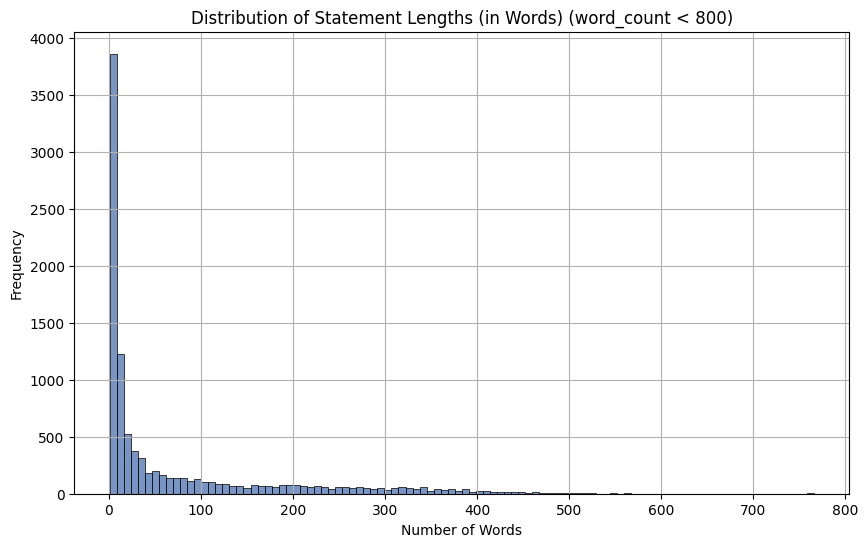

Total number of statements: 9933
Total number of candidates: 36
Total number of speeches over 800 words: 4


In [22]:
plt.figure(figsize=(10, 6))
sns.histplot(df_transcripts[df_transcripts['word_count'] < 800]['word_count'], bins=100, color='#4C72B0')
plt.title('Distribution of Statement Lengths (in Words) (word_count < 800)')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

print (f"Total number of statements: {len(df_transcripts)}")
print(f"Total number of candidates: {df_candidates['actor'].nunique()}")
print(f"Total number of speeches over 800 words: {df_transcripts[df_transcripts['word_count'] > 800].shape[0]}")

We see a clear trend of many statements over very few words in a negatively exponential distribution.

### Explore Statement Length Differences across different Periods

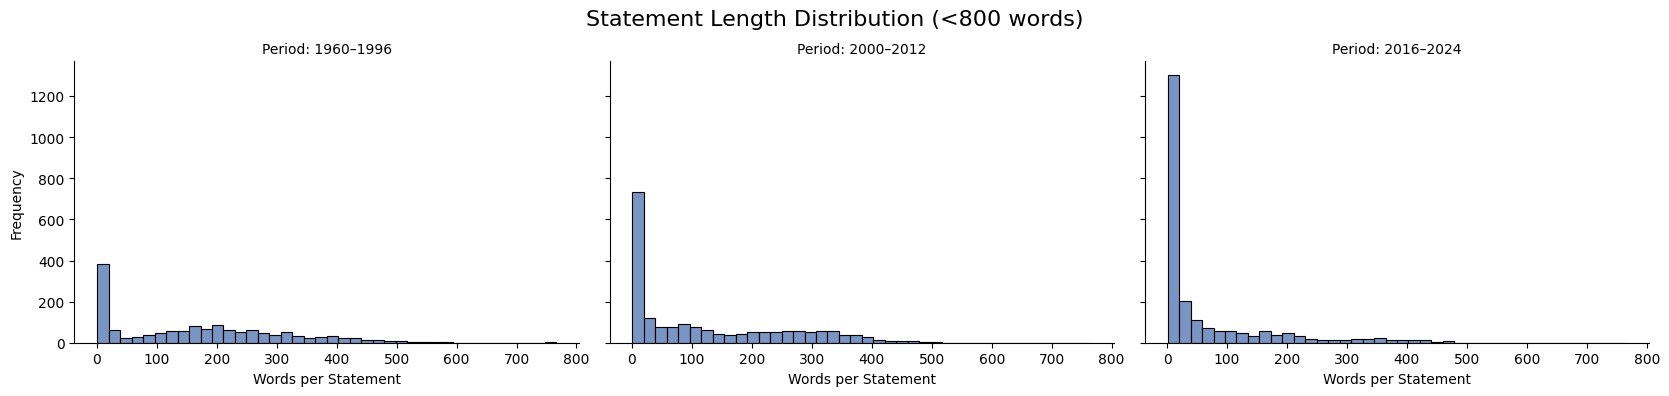

In [23]:
def map_year_block(y):
    if y < 2000:
        return "1960–1996"
    elif y <= 2012:
        return "2000–2012"
    else:
        return "2016–2024"



# Limit to statements under 800 words
df_candidates_sub800 = df_candidates[df_candidates['word_count'] < 800]
df_candidates_sub800['year_block'] = df_candidates_sub800['year'].apply(map_year_block)

g = sns.displot(
    data=df_candidates_sub800,
    x='word_count',
    col='year_block',
    col_order=["1960–1996", "2000–2012", "2016–2024"],
    col_wrap=3,
    height=4,
    aspect=1.4,
    bins=40,
    color='#4C72B0',
    facet_kws={'sharey': True}
)

g.set_titles("Period: {col_name}")
g.set_axis_labels("Words per Statement", "Frequency")
plt.subplots_adjust(top=0.85)
g.fig.suptitle("Statement Length Distribution (<800 words)", fontsize=16)
plt.show()

Especially in recent years, the number of short speeches has exploded. This is especially due to short interruptions.

In [24]:
# Compute average per span
avg_per_span = df_candidates.groupby('year')['word_count'].mean().reset_index(name='avg_statement_length')
print(avg_per_span)

    year  avg_statement_length
0   1960            353.445545
1   1976            278.336207
2   1980            248.962025
3   1984            195.238095
4   1988            159.232759
5   1992            104.437148
6   1996            174.865306
7   2000            145.920424
8   2004            182.181818
9   2008            131.915414
10  2012             77.612991
11  2016             56.208723
12  2020             41.914168
13  2024            150.811258


A similar falling trend is visible in the raw numbers, which show a clear decline in statement length per cycle. Only in 2024, the sentence length has increased again.

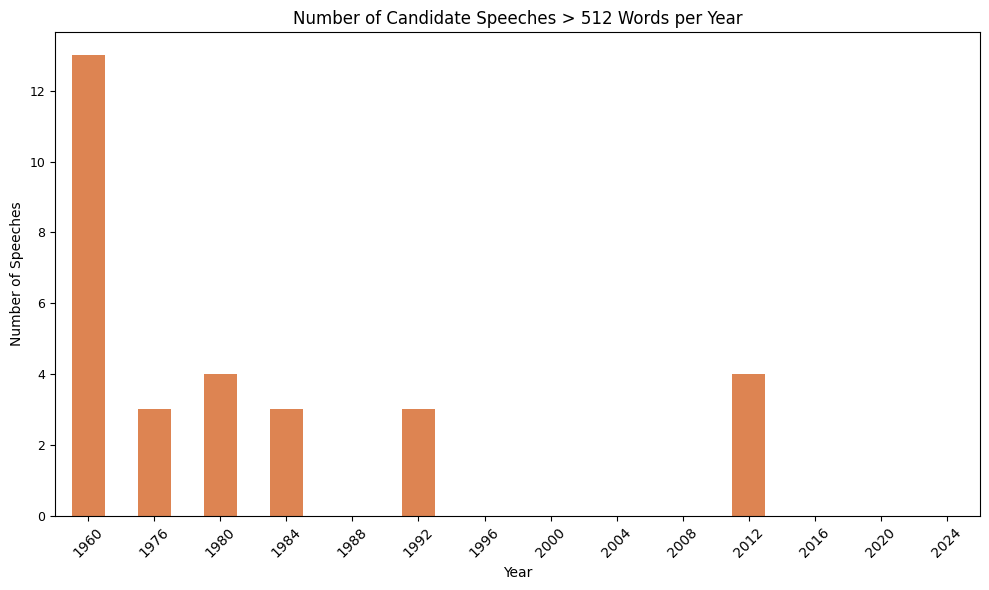

In [25]:
df_transcripts['word_count'] = df_transcripts['dialogue'].apply(lambda x: len(str(x).split()))
long_speeches = df_transcripts[df_transcripts['word_count'] > 512]
long_speeches_per_year = long_speeches.groupby('year').size()
all_years = df_transcripts['year'].unique()
long_speeches_per_year = long_speeches_per_year.reindex(sorted(all_years), fill_value=0)

plt.figure(figsize=(10, 6))
long_speeches_per_year.plot(kind='bar', color='#DD8452')
plt.title('Number of Candidate Speeches > 512 Words per Year')
plt.ylabel('Number of Speeches')
plt.xlabel('Year')
plt.xticks(rotation=45, size=10)
plt.yticks(size=9)
plt.tight_layout()
plt.show()

We notice that only in older debates speeches longer than 512 words were common, while in more recent debates they are rare. This number of 512 words is relevant because it is the maximum length of input for many transformer models, including BERT and its variants. This means that we have to employ chunking techniques to process longer speeches, which can lead to loss of context and coherence in the analysis.

### Explore Number of Words Differences between Candidates 

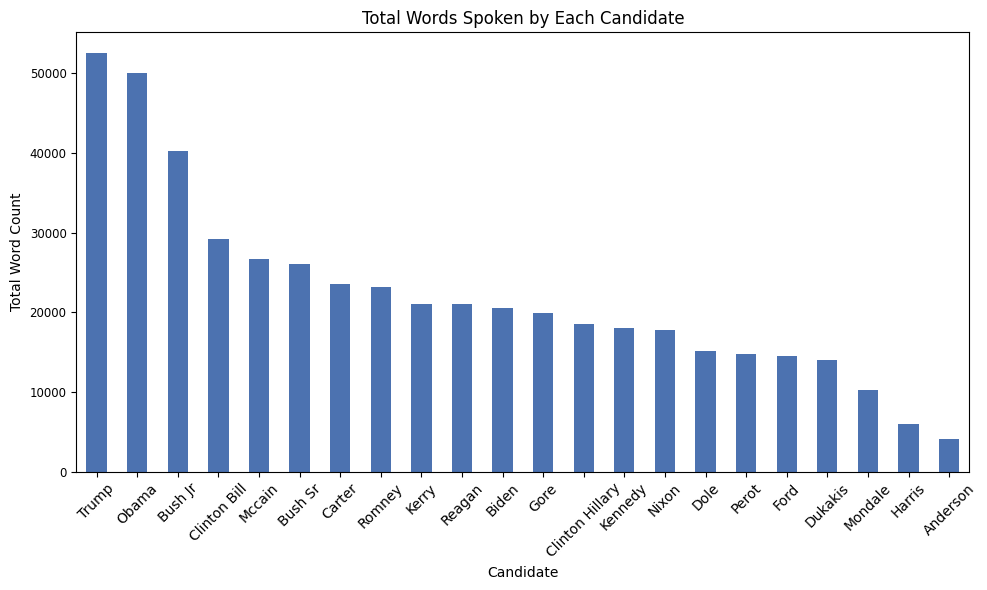

In [26]:
words_per_candidate = df_candidates[(df_candidates['VP_debate'] == False)].groupby('actor')['word_count'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
words_per_candidate.plot(kind='bar', color='#4C72B0')
plt.title('Total Words Spoken by Each Candidate')
plt.ylabel('Total Word Count')
plt.xlabel('Candidate')
plt.xticks(rotation=45, size=10)
plt.yticks(size=8.5)
plt.tight_layout()
plt.show()

We see that Donald Trump and Barack Obama have the most words spoken. However, this may be due to longer debate formats and more frequent appearances, less necessarily being more detailed within a singular debate.

### Explore Total Number of Words Differences between Candidates 

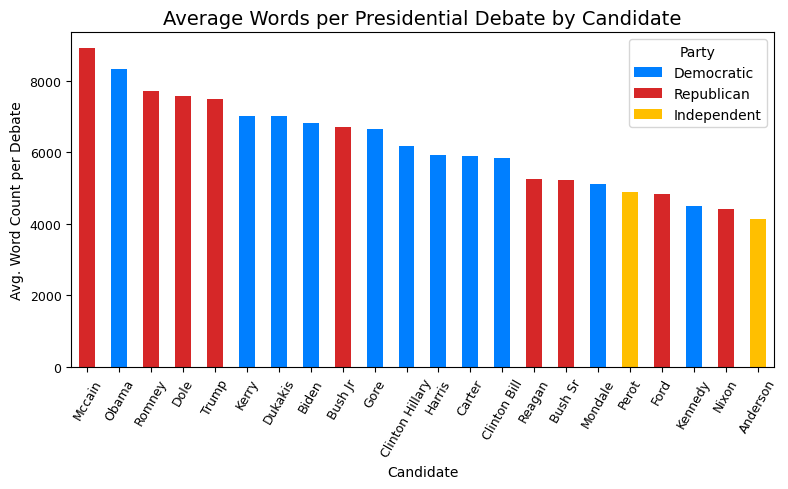

In [27]:
# Prep data
pres_debate = df_candidates[~df_candidates['VP_debate']]

avg_words = (
    pres_debate.groupby(['actor', 'date'])['word_count'].sum()
    .groupby('actor').mean()
    .sort_values(ascending=False)
)

actor_party = pres_debate.groupby('actor')['party'].agg(lambda x: x.mode().iloc[0])

party_palette = {
    'Democratic': '#007FFF',
    'Republican': '#d62728',
    'Independent': '#FFBF00'
}

colors = [party_palette.get(actor_party.get(actor, 'Independent'), '#808080') for actor in avg_words.index]

# Plot
plt.figure(figsize=(8, 5))
avg_words.plot(kind='bar', color=colors)

plt.title('Average Words per Presidential Debate by Candidate', fontsize=14)
plt.ylabel('Avg. Word Count per Debate')
plt.xlabel('Candidate')
plt.xticks(rotation=60, fontsize=9)
plt.yticks(fontsize=9)

plt.legend(
    handles=[
        Patch(facecolor=party_palette['Democratic'], label='Democratic'),
        Patch(facecolor=party_palette['Republican'], label='Republican'),
        Patch(facecolor=party_palette['Independent'], label='Independent')
    ],
    title='Party', loc='upper right'
)

plt.tight_layout()
plt.show()

We notice that actually Mccain, followed by Obama, are the most wordy speakers within a debate.

### Explore most frequent N-grams

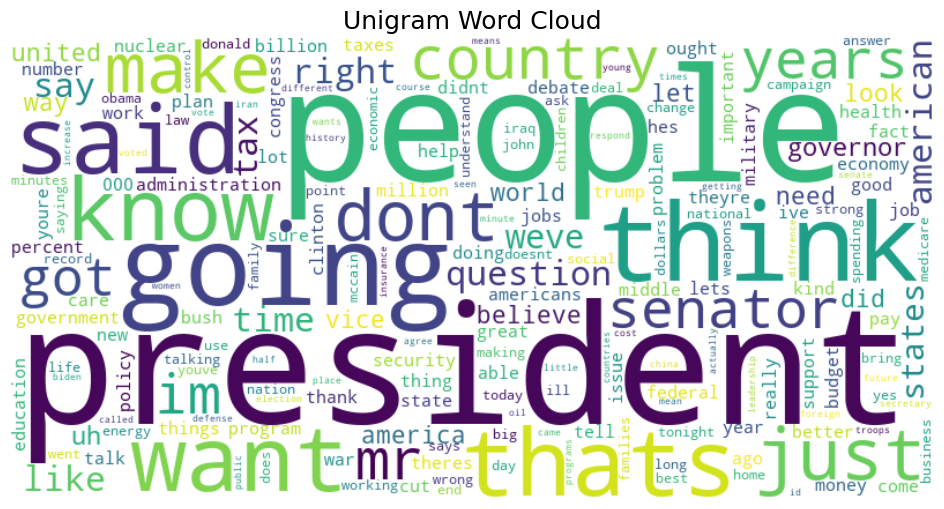

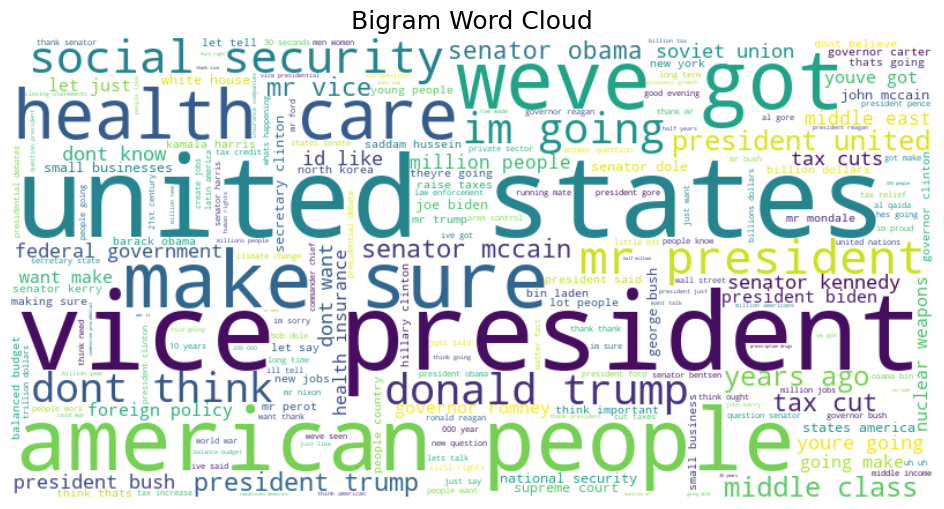

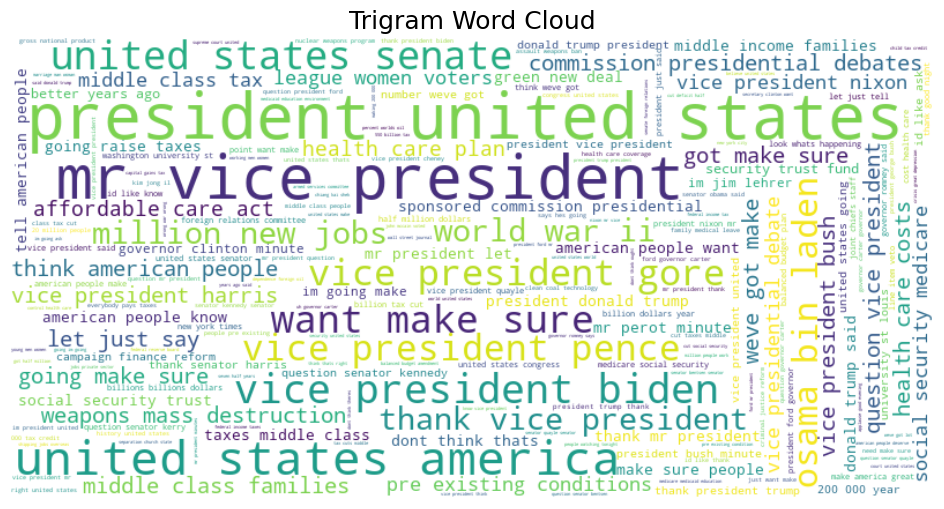

In [28]:

def generate_ngram_wordcloud(text, ngram_range=(1,1), title="Unigram Word Cloud"):
    vectorizer = CountVectorizer(ngram_range=ngram_range, stop_words='english')
    X = vectorizer.fit_transform([text])
    freqs = X.toarray().sum(axis=0)
    vocab = vectorizer.get_feature_names_out()
    freq_dict = dict(zip(vocab, freqs))

    wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(freq_dict)

    plt.figure(figsize=(12, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(title, fontsize=18)
    plt.axis("off")
    plt.show()

text = " ".join(df_transcripts["dialogue"].dropna())

generate_ngram_wordcloud(text, ngram_range=(1,1), title="Unigram Word Cloud")
generate_ngram_wordcloud(text, ngram_range=(2,2), title="Bigram Word Cloud")
generate_ngram_wordcloud(text, ngram_range=(3,3), title="Trigram Word Cloud")

# Sentiment Analysis

### Apply VADER

In [29]:
vader = SentimentIntensityAnalyzer()

In [30]:
%%time
def analyze_vader(text):
    scores = vader.polarity_scores(text)
    return scores

def add_vader_sentiment(df, text_column='dialogue'):
    print("Applying VADER:")
    df['vader_full']= df[text_column].progress_apply(analyze_vader)
    df['vader_sentiment'] = df['vader_full'].apply(lambda x: x['compound'])
    df['vader_label']= df['vader_sentiment'].apply(lambda x: 'positive' if x > 0.05 else ('negative' if x < -0.05 else 'neutral'))
    return df

#Test Output
add_vader_sentiment(df_transcripts.head(20), 'dialogue')

Applying VADER:


100%|██████████| 20/20 [00:00<00:00, 792.58it/s]

CPU times: user 28.2 ms, sys: 17.1 ms, total: 45.3 ms
Wall time: 41.4 ms


,debate_title,date,year,actor,first_name,dialogue,is_candidate,party,is_winner,VP_debate,is_incumbent,word_count,vader_full,vader_sentiment,vader_label
0,1960_Kennedy_Nixon_1,1960-09-26,1960,Kennedy,John,"Mr. Smith, Mr. Nixon. In the election of 1860,...",True,Democratic,True,False,False,1249,"{'neg': 0.074, 'neu': 0.758, 'pos': 0.169, 'co...",0.9993,positive
1,1960_Kennedy_Nixon_1,1960-09-26,1960,Smith,NaN,And now the opening statement by Vice Presiden...,False,NaN,False,False,False,11,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,neutral
2,1960_Kennedy_Nixon_1,1960-09-26,1960,Nixon,Richard,"Mr. Smith, Senator Kennedy. The things that Se...",True,Republican,False,False,False,1382,"{'neg': 0.037, 'neu': 0.834, 'pos': 0.129, 'co...",0.9992,positive
3,1960_Kennedy_Nixon_1,1960-09-26,1960,Smith,NaN,"Thank you, Mr. Nixon. That completes the openi...",False,NaN,False,False,False,62,"{'neg': 0.0, 'neu': 0.961, 'pos': 0.039, 'comp...",0.3612,positive
4,1960_Kennedy_Nixon_1,1960-09-26,1960,Fleming,NaN,"Senator, the Vice President in his campaign ha...",False,NaN,False,False,False,41,"{'neg': 0.05, 'neu': 0.95, 'pos': 0.0, 'compou...",-0.2732,negative
5,1960_Kennedy_Nixon_1,1960-09-26,1960,Kennedy,John,"Well, the Vice President and I came to the Con...",True,Democratic,True,False,False,186,"{'neg': 0.0, 'neu': 0.82, 'pos': 0.18, 'compou...",0.9856,positive
6,1960_Kennedy_Nixon_1,1960-09-26,1960,Smith,NaN,"Mr. Nixon, would you like to comment on that s...",False,NaN,False,False,False,10,"{'neg': 0.0, 'neu': 0.783, 'pos': 0.217, 'comp...",0.3612,positive
7,1960_Kennedy_Nixon_1,1960-09-26,1960,Nixon,Richard,I have no comment.,True,Republican,False,False,False,4,"{'neg': 0.524, 'neu': 0.476, 'pos': 0.0, 'comp...",-0.2960,negative
8,1960_Kennedy_Nixon_1,1960-09-26,1960,Smith,NaN,The next question: Mr. Novins.,False,NaN,False,False,False,5,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,neutral
9,1960_Kennedy_Nixon_1,1960-09-26,1960,Novins,NaN,"Mr. Vice President, your campaign stresses the...",False,NaN,False,False,False,60,"{'neg': 0.047, 'neu': 0.879, 'pos': 0.074, 'co...",0.1779,positive


### Apply RoBERTa

In [31]:
# Load model and tokenizer
model_path = "cardiffnlp/twitter-roberta-base-sentiment-latest"
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)
model.eval()

Some weights of the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
         

In [32]:
# Shared helper: compute sentiment from logits
def compute_sentiment_from_logits(logits):
    probs = softmax(logits.detach().cpu().numpy())
    score_dict = {k: float(v) for k, v in zip(["neg", "neu", "pos"], np.round(probs, 4))}
    polarity_raw = float(np.sum(np.array([-1, 0, 1]) * probs))
    polarity_vader_scaled = float(np.tanh(2 * polarity_raw))
    return pd.Series([score_dict, polarity_raw, polarity_vader_scaled])

In [33]:
# Chunk text into overlapping slices of input_ids
def chunk_text(text, max_length=512, stride=20):
    tokens = tokenizer(text, return_tensors="pt", truncation=False)["input_ids"][0]
    return [tokens[i:i + max_length] for i in range(0, len(tokens), max_length - stride)]

In [34]:
# Sentiment for long texts using chunking
def analyze_long_text(text):
    try:
        token_chunks = chunk_text(text)
        probs_all = []

        for chunk in token_chunks:
            input_ids = chunk.unsqueeze(0)
            attention_mask = torch.ones_like(input_ids)

            with torch.no_grad():
                output = model(input_ids=input_ids, attention_mask=attention_mask)
                probs = softmax(output.logits[0].detach().cpu().numpy())
                probs_all.append(probs)

        avg_probs = np.mean(probs_all, axis=0)
        return compute_sentiment_from_logits(torch.tensor(avg_probs))

    except Exception as e:
        print("Error during long text inference:", e)
        return pd.Series([{"neg": 0.0, "neu": 1.0, "pos": 0.0}, 0.0, 0.0])

In [35]:
# Main function: choose normal or chunked analysis
def analyze_full_sentiment(text, max_length=512):
    try:
        if len(tokenizer.encode(text, truncation=False)) <= max_length:
            encoded = tokenizer(text, return_tensors="pt", truncation=True, max_length=max_length)
            with torch.no_grad():
                output = model(**encoded)
            return compute_sentiment_from_logits(output.logits[0])
        else:
            return analyze_long_text(text)
    except Exception as e:
        print("Error in adaptive sentiment analysis:", e)
        return pd.Series([{"neg": 0.0, "neu": 1.0, "pos": 0.0}, 0.0, 0.0])

# DataFrame application
def add_bert_sentiment(df, text_column="dialogue"):
    print("Applying RoBERTa:")
    df[['bert_full', 'bert_raw', 'bert_sentiment']] = df[text_column].progress_apply(analyze_full_sentiment)
    df['bert_label'] = df['bert_sentiment'].apply(lambda x: 'positive' if x > 0.05 else ('negative' if x < -0.05 else 'neutral'))
    return df

In [36]:
def add_diff_sentiment(df, text_column='dialogue'):
    df = add_vader_sentiment(df, text_column)
    df = add_bert_sentiment(df, text_column)
    df['diff_sentiment'] = df['vader_sentiment'] - df['bert_sentiment']
    return df

In [37]:
%%time
df_candidates = add_diff_sentiment(df_candidates, text_column='dialogue')
df_candidates.to_csv('candidate_transcripts_sentiment.csv', index=False)

Applying VADER:


100%|██████████| 5651/5651 [00:02<00:00, 2298.85it/s]


Applying RoBERTa:


100%|██████████| 5651/5651 [06:44<00:00, 13.96it/s]

CPU times: user 8min 30s, sys: 1min 25s, total: 9min 56s
Wall time: 6min 47s


### See Results

In [39]:
df_candidates=pd.read_csv('candidate_transcripts_sentiment.csv')
df_candidates_pres = df_candidates[(~df_candidates["VP_debate"])]
df_candidates_vice = df_candidates[(df_candidates["VP_debate"])]

#### Checking the Impact of Vice Presidential Debates

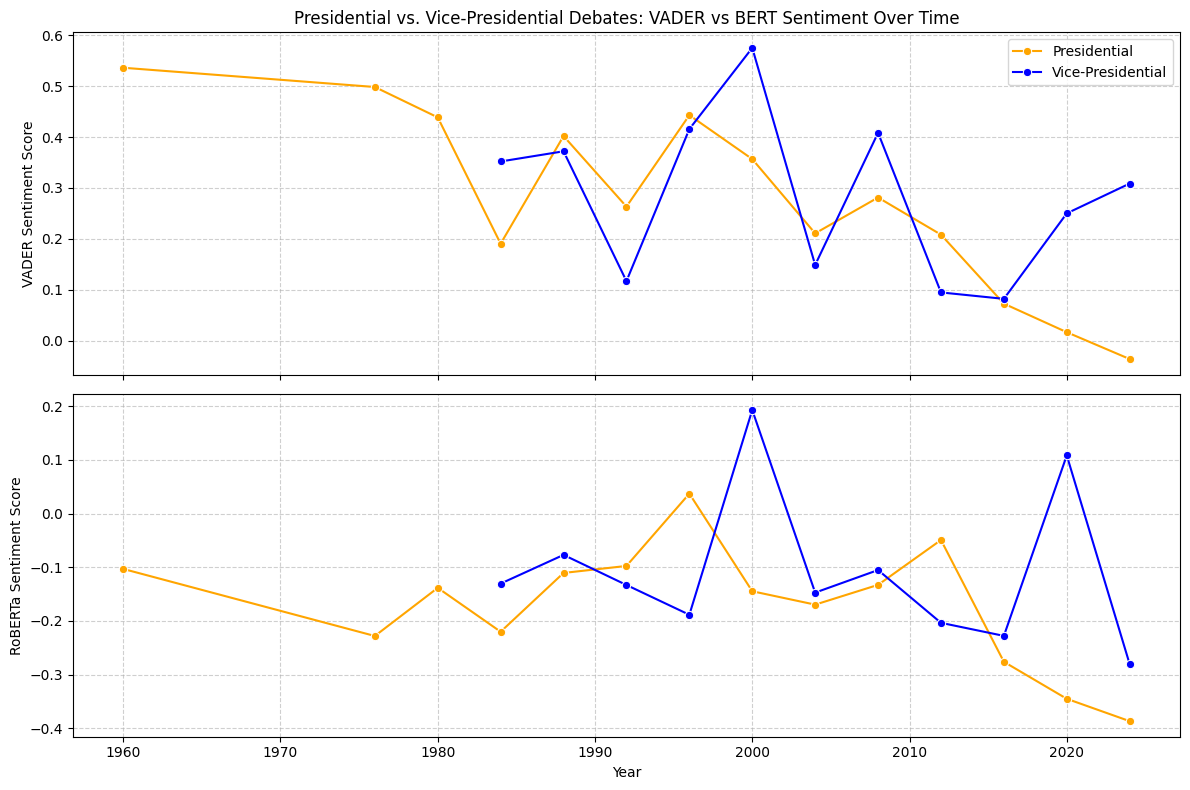

In [40]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

df_pres_debate = df_candidates_pres[(df_candidates_pres["VP_debate"] == False) & (df_candidates_pres["is_candidate"])]
avg_sentiment_pres = df_pres_debate.groupby(['date', 'year'])[['bert_sentiment', 'vader_sentiment']].mean().reset_index()

df_vice_debate = df_candidates_vice[(df_candidates_vice["VP_debate"] == True) & (df_candidates_vice["is_candidate"])]
avg_sentiment_vice = df_vice_debate.groupby(['date', 'year'])[['bert_sentiment', 'vader_sentiment']].mean().reset_index()

# Plot 1: All Debates
sns.lineplot(data=avg_sentiment_pres, x='year', y='vader_sentiment', ax=axes[0], label='Presidential', color='orange', marker='o', errorbar=None)
sns.lineplot(data=avg_sentiment_vice, x='year', y='vader_sentiment', ax=axes[0], label='Vice-Presidential', color='blue', marker='o', errorbar=None)
axes[0].set_title('Presidential vs. Vice-Presidential Debates: VADER vs BERT Sentiment Over Time')
axes[0].set_ylabel('VADER Sentiment Score')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.6)

# Plot 2: Presidential Debates
sns.lineplot(data=avg_sentiment_pres, x='year', y='bert_sentiment', ax=axes[1], color='orange', marker='o', errorbar=None)
sns.lineplot(data=avg_sentiment_vice, x='year', y='bert_sentiment', ax=axes[1], color='blue', marker='o', errorbar=None)
axes[1].set_title('')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('RoBERTa Sentiment Score')
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

We can clearly see that vice presidential debates are often massive outlier compared to their presidential counterparts. Due to this, we want to focus on only presidential debates for the sentiment analysis, as the sentiments of the actual presidential debate is most central to our research

#### Polarity Distribution across Presidential Debates

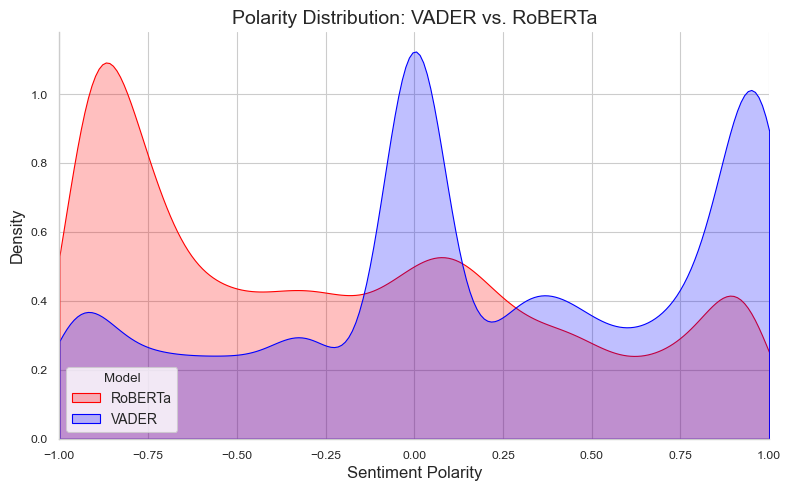

In [42]:
plt.figure(figsize=(8, 5))
sns.set(style="whitegrid", palette="colorblind", context="paper")

# KDE plot for RoBERTa and VADER
sns.kdeplot(df_candidates_pres["bert_sentiment"], color="red", fill=True, label="RoBERTa", bw_adjust=0.75, clip=(-1, 1))
sns.kdeplot(df_candidates_pres["vader_sentiment"], color="blue", fill=True, label="VADER",  bw_adjust=0.75, clip=(-1, 1))
plt.xlim(-1, 1)
plt.xlabel("Sentiment Polarity", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.title("Polarity Distribution: VADER vs. RoBERTa", fontsize=14)
plt.legend(title="Model", fontsize=10)
sns.despine()
plt.tight_layout()
plt.show()

#### Label Distribution across Presidential Debates

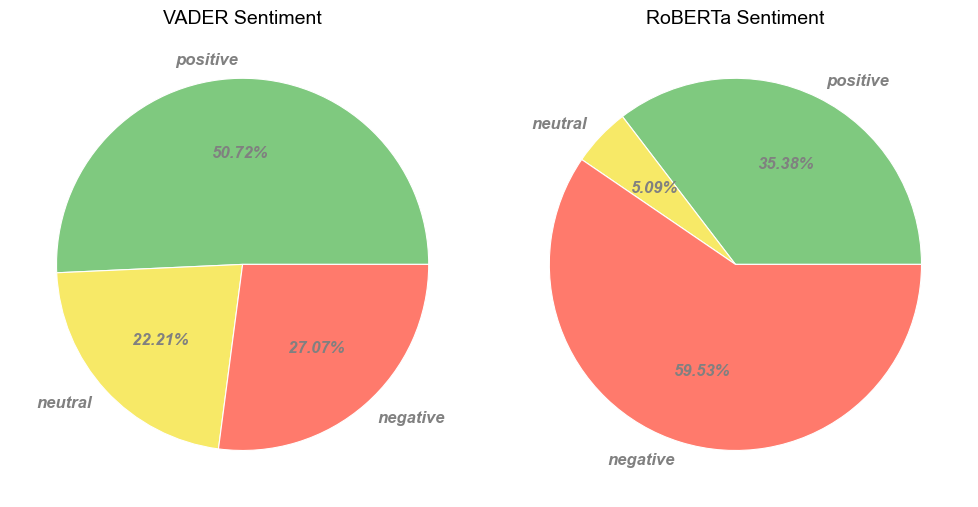

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

color_map = {
    "positive": "#7FC97F",  # green
    "neutral":  "#F7E967",   # yellow
    "negative": "#ff7a6c"   # red
}

textprops = dict(fontsize=12, fontstyle="italic", weight="bold", color="grey")

# VADER pie chart
vader_counts = df_candidates_pres["vader_label"].value_counts(normalize=True)
vader_labels = ["positive", "neutral", "negative"]
vader_colors = [color_map[label] for label in vader_labels if label in vader_counts.index]
vader_counts = vader_counts.reindex(vader_labels).dropna()

axes[0].pie(
    vader_counts,
    labels=vader_counts.index,
    autopct="%.2f%%",
    colors=vader_colors,
    textprops=textprops
)
axes[0].set_title("VADER Sentiment", fontsize=14, color="black")

# RoBERTa pie chart
bert_counts = df_candidates_pres["bert_label"].value_counts(normalize=True)
bert_labels = ["positive", "neutral", "negative"]
bert_colors = [color_map[label] for label in bert_labels if label in bert_counts.index]
bert_counts = bert_counts.reindex(bert_labels).dropna()

axes[1].pie(
    bert_counts,
    labels=bert_counts.index,
    autopct="%.2f%%",
    colors=bert_colors,
    textprops=textprops
)
axes[1].set_title("RoBERTa Sentiment", fontsize=14, color="black")

plt.tight_layout()
plt.show()

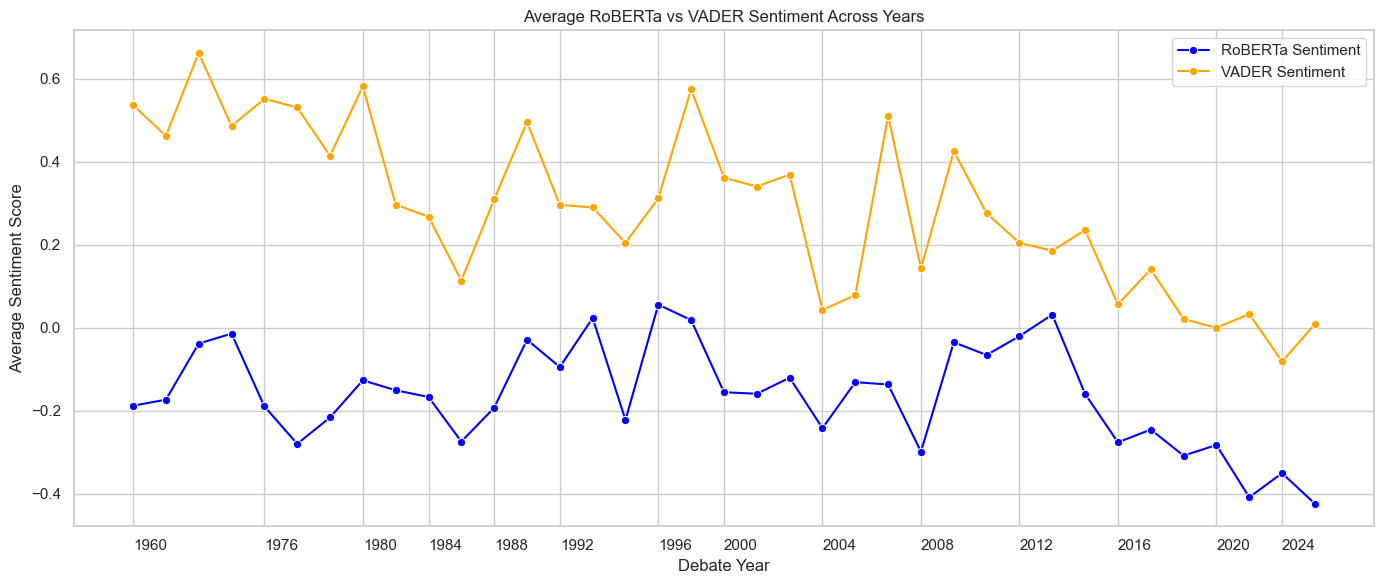

In [58]:
avg_sentiment = df_candidates_pres.groupby(['debate_title', 'year'])[['bert_sentiment', 'vader_sentiment']].mean().reset_index()
sns.set(style='whitegrid')
plt.figure(figsize=(14, 6))

sns.lineplot(data=avg_sentiment, x='debate_title', y='bert_sentiment', label='RoBERTa Sentiment', color='blue', marker='o')
sns.lineplot(data=avg_sentiment, x='debate_title', y='vader_sentiment', label='VADER Sentiment', color='orange', marker='o')

# Base tick positions: every 4th
year_changes = avg_sentiment['year'] != avg_sentiment['year'].shift(1)
tick_positions = avg_sentiment.index[year_changes].tolist()
tick_labels = avg_sentiment['year'][year_changes].tolist()
plt.xticks(ticks=tick_positions, labels=tick_labels,ha='left')


plt.title('Average RoBERTa vs VADER Sentiment Across Years')
plt.xlabel('Debate Year')
plt.ylabel('Average Sentiment Score')
plt.legend()
plt.tight_layout()
plt.show()

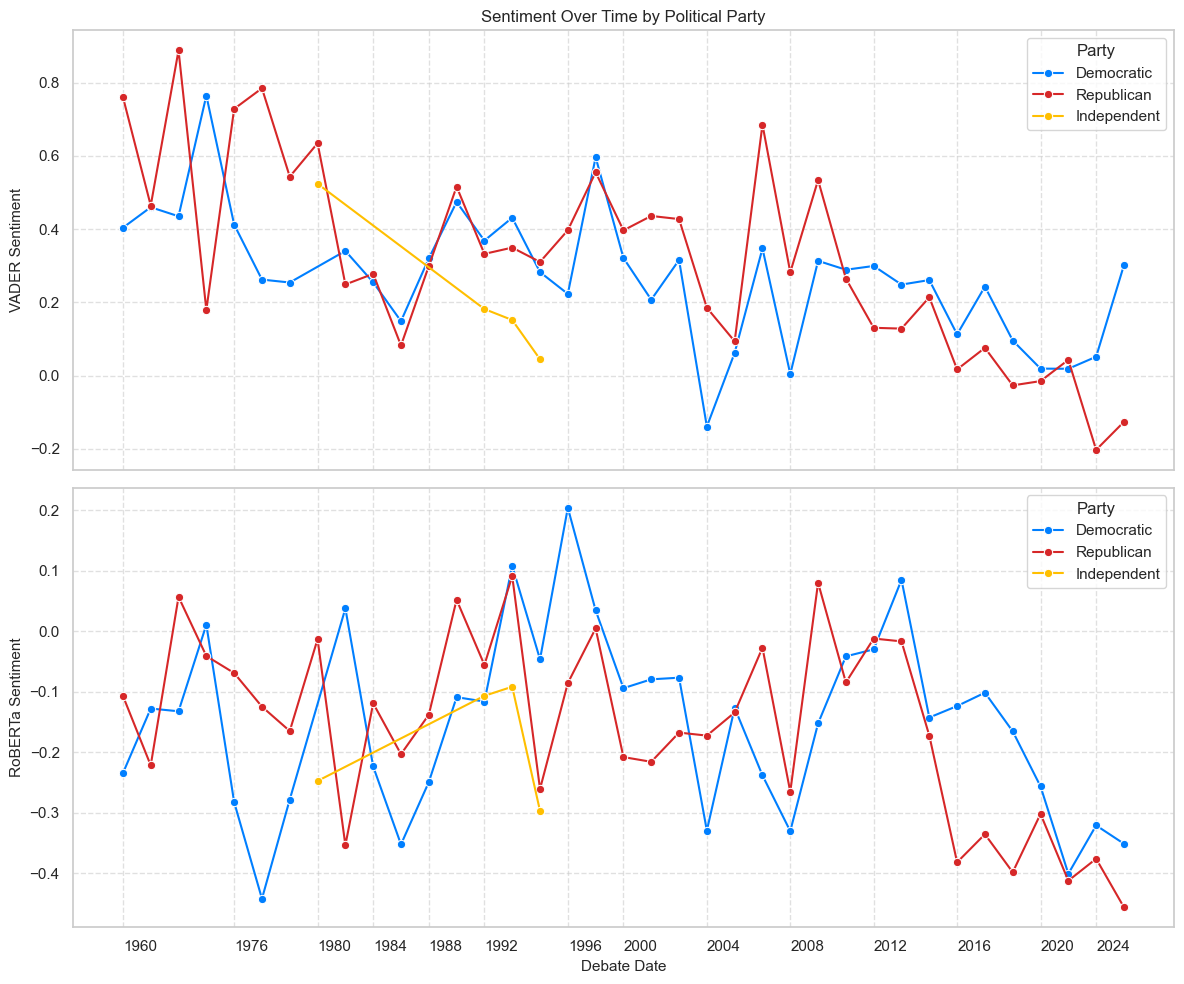

In [59]:
avg_sentiment_party = df_candidates_pres.groupby(['date', 'year', 'party'])[['bert_sentiment', 'vader_sentiment']].mean().reset_index()

sns.set(style='whitegrid')

party_palette = {
    'Democratic': '#007FFF',   # Blue
    'Republican': '#d62728',   # Red
    'Independent': '#FFBF00'   # Yellow
}

#Labels per year
unique_dates = avg_sentiment_party[['date', 'year']].drop_duplicates().sort_values('date').reset_index(drop=True)
year_changes = unique_dates['year'] != unique_dates['year'].shift(1)
tick_positions = unique_dates['date'][year_changes].tolist()
tick_labels = unique_dates['year'][year_changes].tolist()

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12, 10), sharex=True)

#VADER PLOT
sns.lineplot(
    data=avg_sentiment_party,
    x='date',
    y='vader_sentiment',
    hue='party',
    marker='o',
    errorbar=None,
    palette=party_palette,
    ax=axes[0]
)
axes[0].set_title('Sentiment Over Time by Political Party')
axes[0].set_ylabel('VADER Sentiment', size=11)
axes[0].legend(title='Party')
axes[0].grid(True, linestyle='--', alpha=0.6)


#BERT PLOT
sns.lineplot(
    data=avg_sentiment_party,
    x='date',
    y='bert_sentiment',
    hue='party',
    marker='o',
    errorbar=None,
    palette=party_palette,
    ax=axes[1]
)
axes[1].set_xlabel('Debate Date', size=11)
axes[1].set_ylabel('RoBERTa Sentiment', size=11)
axes[1].legend(title='Party')
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.xticks(ticks=tick_positions, labels=tick_labels, ha='left')

plt.tight_layout()
plt.show()

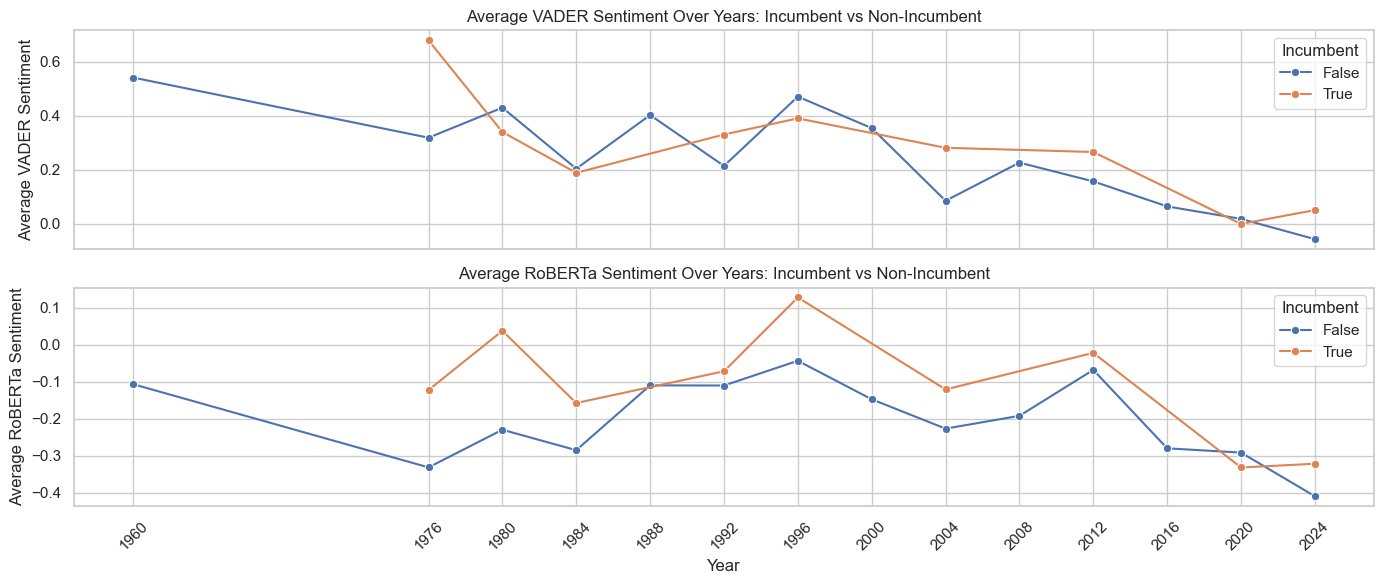

In [60]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

#VADER
sns.lineplot(
    data=df_candidates_pres,
    x='year',
    y='vader_sentiment',
    hue='is_incumbent',
    errorbar=None,
    marker='o',
    ax=axes[0]
)
axes[0].set_title('Average VADER Sentiment Over Years: Incumbent vs Non-Incumbent')
axes[0].set_ylabel('Average VADER Sentiment')
axes[0].legend(title='Incumbent')
axes[0].grid(True)

#RoBERTa
sns.lineplot(
    data=df_candidates_pres,
    x='year',
    y='bert_sentiment',
    hue='is_incumbent',
    errorbar=None,
    marker='o',
    ax=axes[1]
)
axes[1].set_title('Average RoBERTa Sentiment Over Years: Incumbent vs Non-Incumbent')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Average RoBERTa Sentiment')
axes[1].legend(title='Incumbent')
axes[1].grid(True)

unique_years = sorted(df_candidates_pres['year'].unique())
axes[1].set_xticks(unique_years)
axes[1].set_xticklabels(unique_years, rotation=45)

plt.tight_layout()
plt.show()

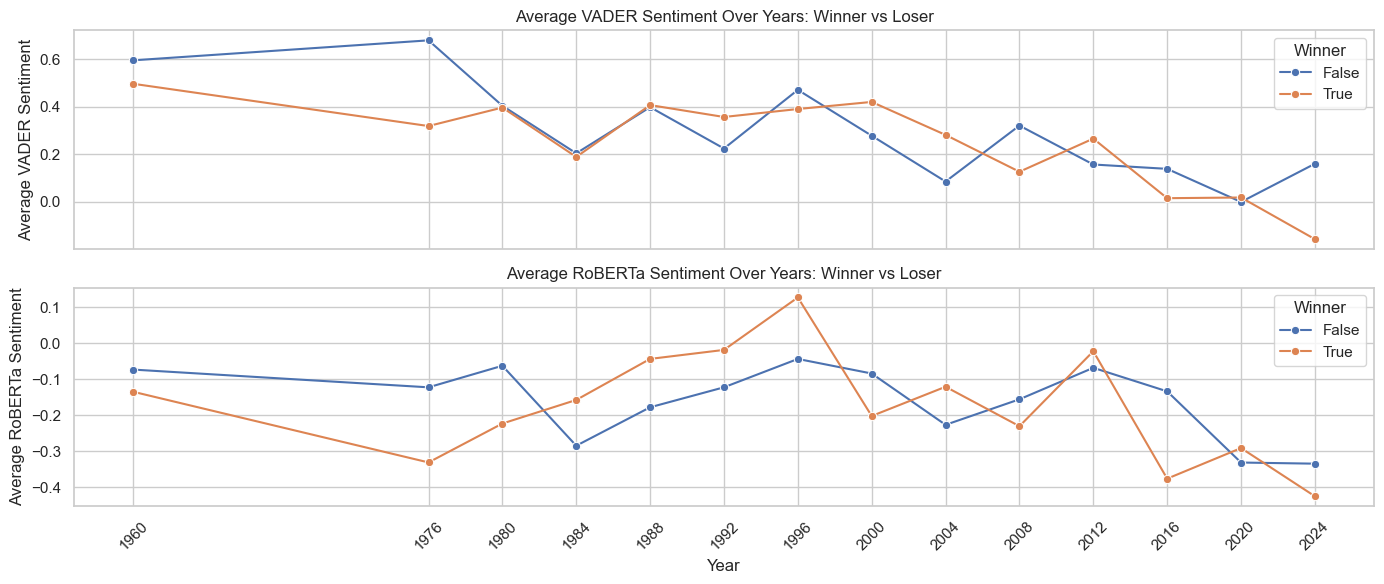

In [61]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

#VADER
sns.lineplot(
    data=df_candidates_pres,
    x='year',
    y='vader_sentiment',
    hue='is_winner',
    errorbar=None,
    marker='o',
    ax=axes[0]
)
axes[0].set_title('Average VADER Sentiment Over Years: Winner vs Loser')
axes[0].set_ylabel('Average VADER Sentiment')
axes[0].legend(title='Winner')
axes[0].grid(True)

#ROBERTA
sns.lineplot(
    data=df_candidates_pres,
    x='year',
    y='bert_sentiment',
    hue='is_winner',
    errorbar=None,
    marker='o',
    ax=axes[1]
)
axes[1].set_title('Average RoBERTa Sentiment Over Years: Winner vs Loser')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Average RoBERTa Sentiment')
axes[1].legend(title='Winner')
axes[1].grid(True)

unique_years = sorted(df_candidates_pres['year'].unique())
axes[1].set_xticks(unique_years)
axes[1].set_xticklabels(unique_years, rotation=45)

plt.tight_layout()
plt.show()

## Analysis of Trump

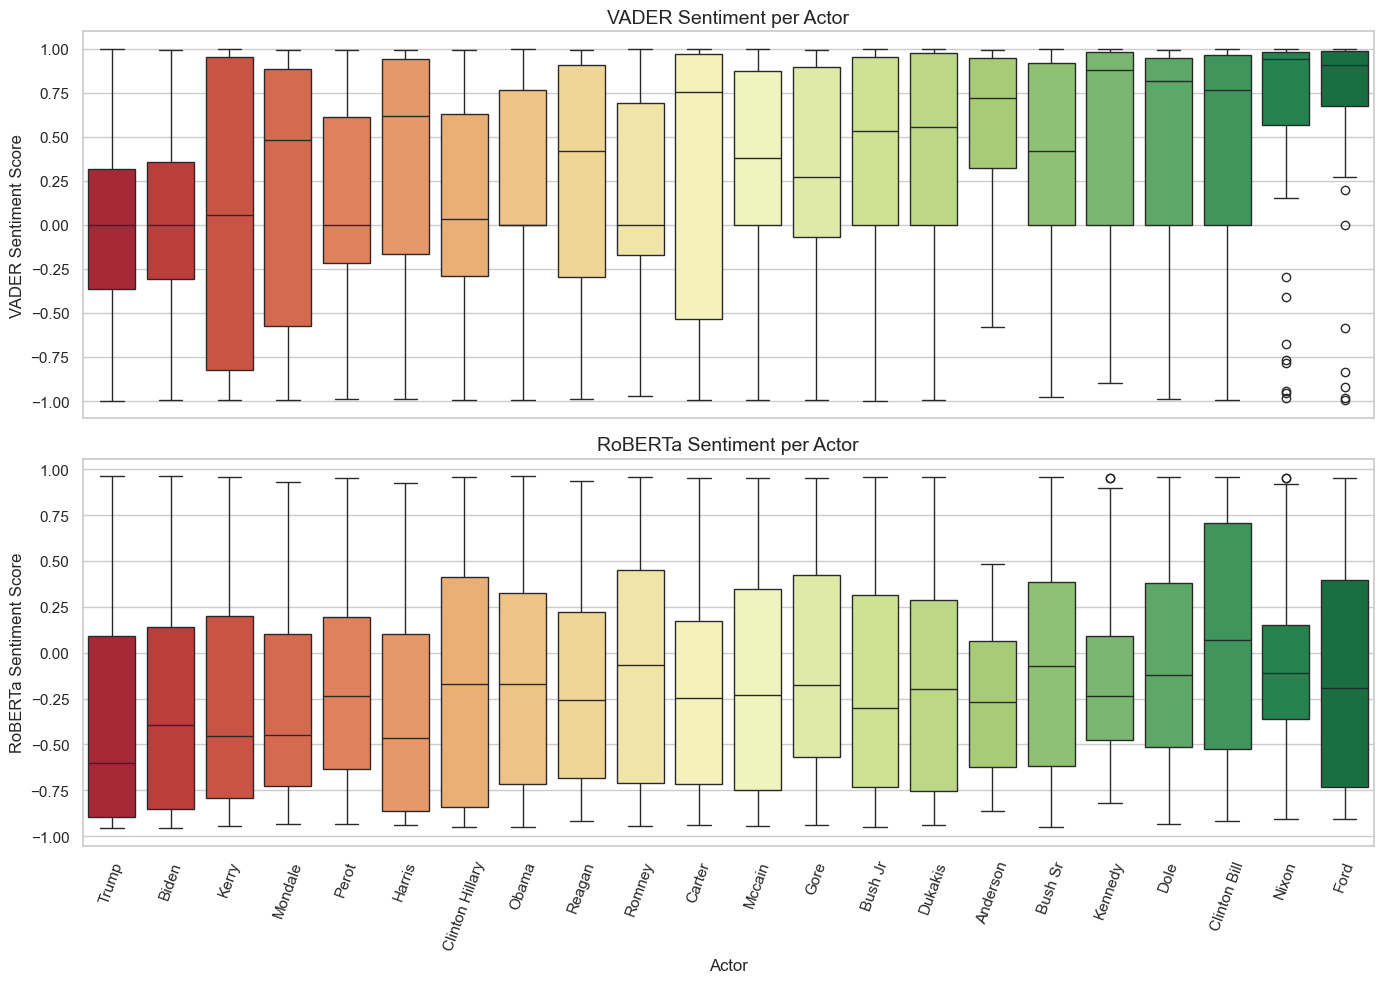

In [65]:
# Calculate mean sentiment per actor for consistent ordering
mean_vader = df_candidates_pres.groupby('actor')['vader_sentiment'].mean()
mean_bert = df_candidates_pres.groupby('actor')['bert_sentiment'].mean()

# Use average of both means to set a common actor order
mean_combined = ((mean_vader + mean_bert) / 2).sort_values()
actor_order = mean_combined.index


fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# VADER boxplot
sns.boxplot(
    data=df_pres_debate,
    x='actor',
    y='vader_sentiment',
    order=actor_order,
    palette='RdYlGn',
    ax=axes[0]
)
axes[0].set_title('VADER Sentiment per Actor', fontsize=14)
axes[0].set_ylabel('VADER Sentiment Score', fontsize=12)
axes[0].tick_params(axis='x', rotation=70)

# BERT boxplot
sns.boxplot(
    data=df_pres_debate,
    x='actor',
    y='bert_sentiment',
    order=actor_order,
    palette='RdYlGn',
    ax=axes[1]
)
axes[1].set_title('RoBERTa Sentiment per Actor', fontsize=14)
axes[1].set_xlabel('Actor', fontsize=12)
axes[1].set_ylabel('RoBERTa Sentiment Score', fontsize=12)
axes[1].tick_params(axis='x', rotation=70)

plt.tight_layout()
plt.show()

In [66]:
df_trump = df_candidates_pres[df_candidates_pres['actor']=='Trump']

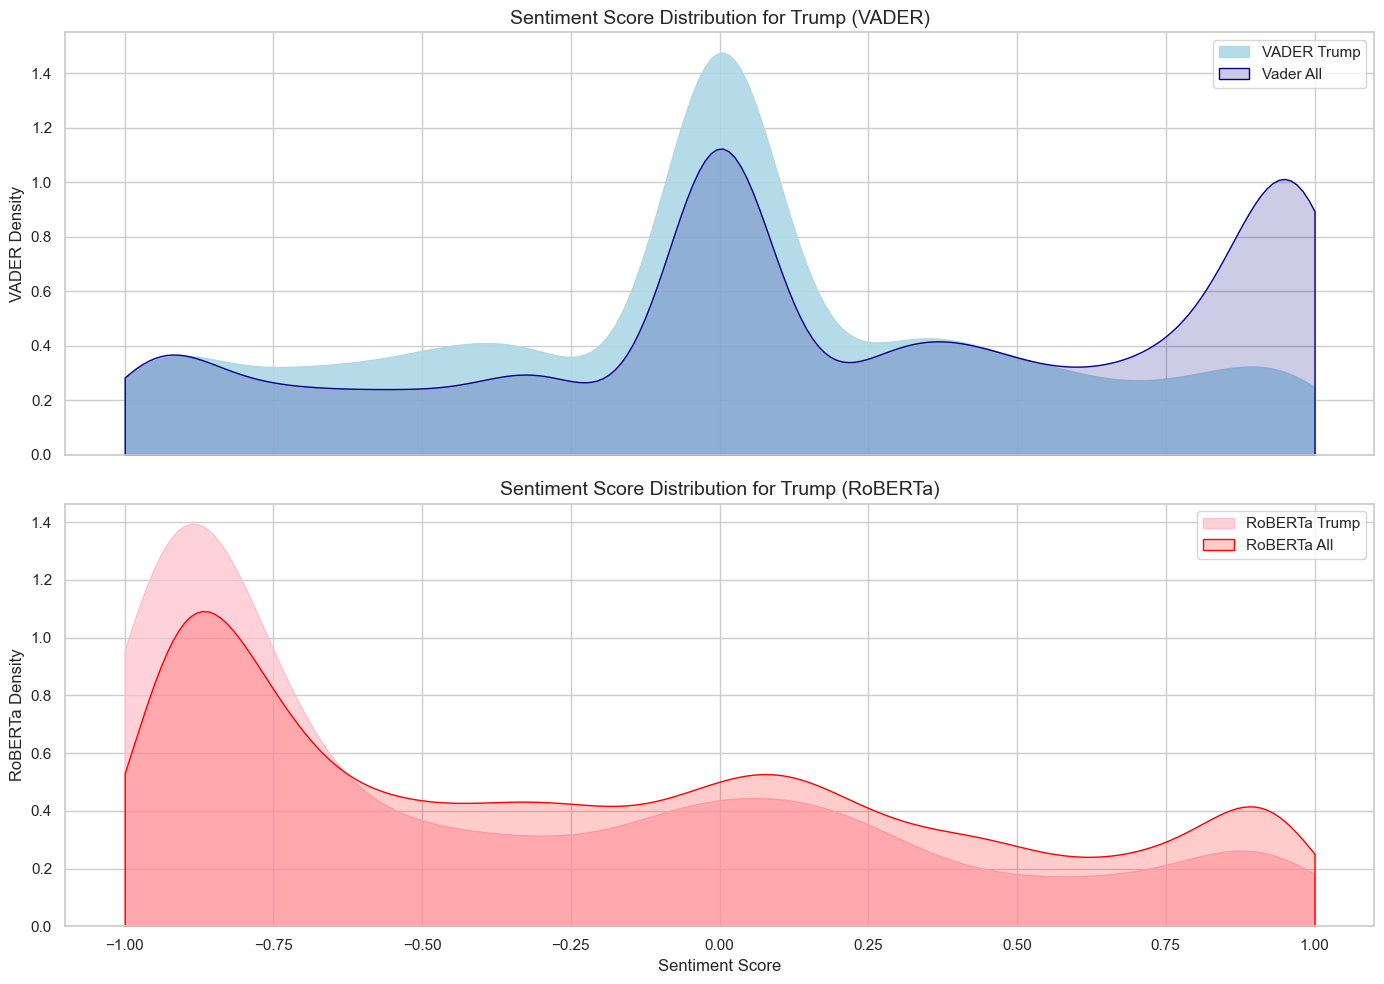

In [76]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

sns.kdeplot(df_trump['vader_sentiment'], label='VADER Trump', fill=True, color='lightblue',bw_adjust=0.75,alpha=0.9, clip=(-1, 1), ax=axes[0])
sns.kdeplot(df_candidates_pres['vader_sentiment'], label='Vader All', fill=True, color='darkblue', alpha=0.2,bw_adjust=0.75, clip=(-1, 1), ax=axes[0])
axes[0].set_title('Sentiment Score Distribution for Trump (VADER)', fontsize=14)
axes[0].set_ylabel('VADER Density', fontsize=12)
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend()

sns.kdeplot(df_trump['bert_sentiment'], label='RoBERTa Trump', fill=True, color='pink', alpha=0.7,bw_adjust=0.75, clip=(-1, 1), ax=axes[1])
sns.kdeplot(df_candidates_pres['bert_sentiment'], label='RoBERTa All', fill=True, color='red', alpha=0.2,bw_adjust=0.75, clip=(-1, 1), ax=axes[1])
axes[1].set_title('Sentiment Score Distribution for Trump (RoBERTa)', fontsize=14)
axes[1].set_xlabel('Sentiment Score', fontsize=12)
axes[1].set_ylabel('RoBERTa Density', fontsize=12)
axes[1].tick_params(axis='x', rotation=0)

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

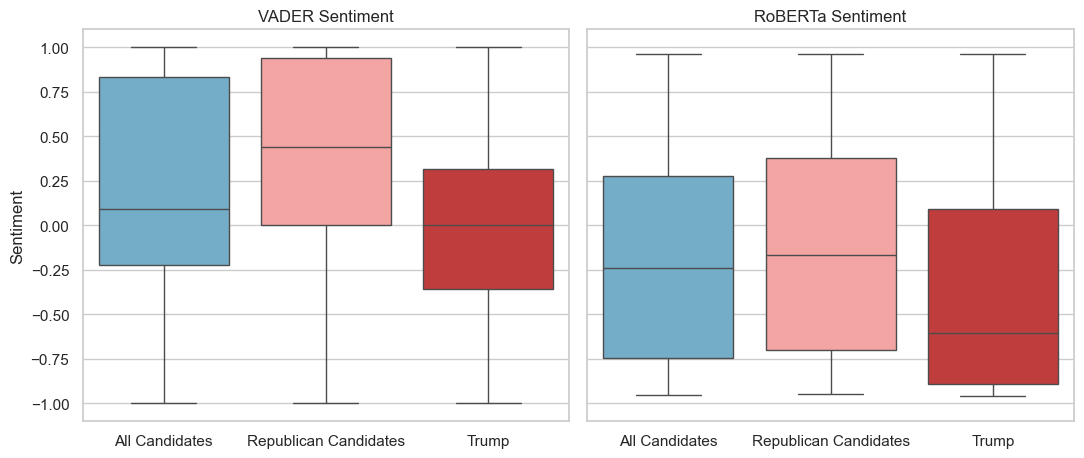

In [77]:
df_candidates_pres['group'] = 'All Candidates'
df_candidates_pres.loc[df_candidates_pres['actor']=='Trump', 'group'] = 'Trump'
df_candidates_pres.loc[
    (df_candidates_pres['party']== 'Republican') &
    ~(df_candidates_pres['actor']=='Trump'),
    'group'
] = 'Republican Candidates'

# Color palette
custom_palette = {
    'All Candidates': '#66b2d6',
    'Republican Candidates': '#ff9896',
    'Trump': '#d62728'
}

# Create side-by-side box plots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(11, 5), sharey=True)

# VADER (left)
sns.boxplot(data=df_candidates_pres, x='group', y='vader_sentiment', palette=custom_palette, ax=axes[0])
axes[0].set_title('VADER Sentiment')
axes[0].set_xlabel('')
axes[0].set_ylabel('Sentiment')
axes[0].grid(True, axis='y')

# RoBERTa (right)
sns.boxplot(data=df_candidates_pres, x='group', y='bert_sentiment', palette=custom_palette, ax=axes[1])
axes[1].set_title('RoBERTa Sentiment')
axes[1].set_xlabel('')
axes[1].set_ylabel('')
axes[1].grid(True, axis='y')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Topic Modeling

## Preprocess Data specifically for LDA and LDASeqModel

In [78]:
# Initialize tools
tokenizer = TreebankWordTokenizer()
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Preprocessing text
def text_preprocess(text):
    if pd.isnull(text):
        return ""
    tokens = tokenizer.tokenize(text)
    filtered_tokens = [word.lower() for word in tokens if word.isalpha() and word.lower() not in stop_words]
    lemmatized_tokens = [lemmatizer.lemmatize(token) for token in filtered_tokens]
    return " ".join(lemmatized_tokens)
df_transcripts["preprocessed_text"] = df_transcripts["dialogue"].progress_apply(text_preprocess)

# Preview
df_transcripts[["dialogue", "preprocessed_text"]].head(10)

100%|██████████| 9933/9933 [00:04<00:00, 2145.24it/s]


,dialogue,preprocessed_text
0,"Mr. Smith, Mr. Nixon. In the election of 1860,...",smith election abraham lincoln said question w...
1,And now the opening statement by Vice Presiden...,opening statement vice president richard nixon
2,"Mr. Smith, Senator Kennedy. The things that Se...",smith senator thing senator kennedy said many ...
3,"Thank you, Mr. Nixon. That completes the openi...",thank completes opening statement candidate an...
4,"Senator, the Vice President in his campaign ha...",senator vice president campaign said naive tim...
5,"Well, the Vice President and I came to the Con...",well vice president came congress together ser...
6,"Mr. Nixon, would you like to comment on that s...",nixon would like comment statement
7,I have no comment.,comment
8,The next question: Mr. Novins.,next question novins
9,"Mr. Vice President, your campaign stresses the...",vice president campaign stress value eight yea...


In [79]:
# Function for Filtering NOUN, ADJ, PROPN
def keep_nouns_adjectives_spacy(text):
    if pd.isnull(text):
        return ""
    doc = nlp(text)
    return " ".join([token.text.lower() for token in doc if token.pos_ in {"NOUN", "ADJ", "PROPN"}])

df_transcripts["preprocessed_text"] = df_transcripts["preprocessed_text"].progress_apply(keep_nouns_adjectives_spacy)

100%|██████████| 9933/9933 [00:59<00:00, 165.83it/s]


In [80]:
# Collect lowercase names from the data
actor_words_to_remove = set(df_transcripts['actor'].dropna().str.lower().str.strip())
first_names_to_remove = set(name.lower() for name in CANDIDATE_FIRST_NAMES.values())
names_to_remove = actor_words_to_remove.union(first_names_to_remove)
names_to_remove.update(["clinton", "bush"])  # extra catch-all

def remove_names(text):
    if pd.isnull(text):
        return text
    tokens = text.split()
    cleaned_tokens = [word for word in tokens if word.lower() not in names_to_remove]
    return " ".join(cleaned_tokens)


df_transcripts["preprocessed_text"] = df_transcripts["preprocessed_text"].progress_apply(remove_names)

100%|██████████| 9933/9933 [00:00<00:00, 135563.40it/s]


In [81]:
#Show top 300 words to check data cleanliness
all_text = " ".join(df_transcripts["preprocessed_text"].dropna())
words = all_text.split()
word_counts = Counter(words)
top_300_df = word_counts.most_common(300)
top_words=[word for word, _ in top_300_df]
pd.set_option('display.max_rows', 300)
top_300_df

[('president', 3854),
 ('people', 3375),
 ('tax', 1786),
 ('year', 1782),
 ('american', 1726),
 ('senator', 1570),
 ('country', 1529),
 ('state', 1507),
 ('time', 1394),
 ('thing', 1255),
 ('governor', 1236),
 ('job', 1021),
 ('united', 1016),
 ('way', 1002),
 ('vice', 999),
 ('america', 943),
 ('new', 894),
 ('government', 870),
 ('world', 849),
 ('good', 818),
 ('right', 808),
 ('last', 790),
 ('plan', 759),
 ('lot', 729),
 ('fact', 710),
 ('first', 693),
 ('health', 689),
 ('sure', 683),
 ('administration', 665),
 ('money', 665),
 ('care', 651),
 ('program', 625),
 ('family', 615),
 ('many', 607),
 ('security', 598),
 ('number', 585),
 ('issue', 573),
 ('war', 569),
 ('great', 548),
 ('minute', 545),
 ('work', 542),
 ('problem', 542),
 ('percent', 534),
 ('talk', 529),
 ('important', 525),
 ('policy', 520),
 ('nation', 514),
 ('kind', 513),
 ('economy', 505),
 ('business', 499),
 ('able', 498),
 ('next', 495),
 ('child', 489),
 ('federal', 489),
 ('know', 480),
 ('day', 470),
 ('cut

In [82]:
# Define exception list
exception_words = {
    "tax", "job", "right", "health", "money", "care", "family", "program",
    "work", "security", "war", "business", "economy", "child", "cut", "nuclear",
    "school", "military", "woman", "budget", "social", "energy", "economic", "life",
    "law", "dollar", "education", "deal", "rate", "ill", "middle", "support",
    "weapon", "system", "cost", "drug", "young", "decision", "company", "iraq",
    "troop", "foreign", "medicare", "help", "force", "course", "oil", "defense",
    "opportunity", "soviet", "deficit", "kid", "china", "iran", "control", "increase",
    "insurance", "income", "pay", "trade", "house", "case", "power", "credit",
    "community", "word", "peace", "union", "ally", "russia", "court", "growth",
    "debt", "freedom", "effort", "use", "border", "order", "chance", "class",
    "terrorist", "college", "teacher", "action", "threat", "parent", "strength",
    "crime", "afghanistan", "arm", "call", "gun", "inflation", "member", "clean",
    "unemployment", "top", "israel", "price", "benefit", "taxpayer", "market",
    "worker", "justice", "saddam", "housing", "investment", "safe", "fund", "east",
    "russian", "sanction", "abortion", "police", "love", "regard", "fight", "lower",
    "crisis", "human", "attack", "industry", "welfare"
}

# Compute frequent words to remove (excluding exceptions)
top_words_set = set(top_words)
words_to_remove = top_words_set - exception_words

# Clean function with filtering
def clean_with_exceptions(text):
    if pd.isnull(text):
        return ""
    tokens = text.split()
    filtered_tokens = [word for word in tokens if word.lower() not in words_to_remove]
    return " ".join(filtered_tokens)
    
df_transcripts["preprocessed_text"] = df_transcripts["preprocessed_text"].progress_apply(clean_with_exceptions)

# Preview result
df_transcripts[["actor", "dialogue", "preprocessed_text"]].head(10)

100%|██████████| 9933/9933 [00:00<00:00, 110815.92it/s]


,actor,dialogue,preprocessed_text
0,Kennedy,"Mr. Smith, Mr. Nixon. In the election of 1860,...",abraham lincoln direction freedom direction ro...
1,Smith,And now the opening statement by Vice Presiden...,opening
2,Nixon,"Mr. Smith, Senator Kennedy. The things that Se...",discus internal affair tremendous internationa...
3,Smith,"Thank you, Mr. Nixon. That completes the openi...",completes comment anothers correspondent corre...
4,Fleming,"Senator, the Vice President in his campaign ha...",naive
5,Kennedy,"Well, the Vice President and I came to the Con...",labor program advocate century woodrow wilson ...
6,Smith,"Mr. Nixon, would you like to comment on that s...",comment
7,Nixon,I have no comment.,comment
8,Smith,The next question: Mr. Novins.,
9,Novins,"Mr. Vice President, your campaign stresses the...",stress observer participant initiator


In [83]:
# Drop rows where preprocessed_text is empty or just whitespace
df_transcripts = df_transcripts[df_transcripts["preprocessed_text"].str.strip() != ""]
df_transcripts[["actor", "dialogue", "preprocessed_text"]].head(10)

,actor,dialogue,preprocessed_text
0,Kennedy,"Mr. Smith, Mr. Nixon. In the election of 1860,...",abraham lincoln direction freedom direction ro...
1,Smith,And now the opening statement by Vice Presiden...,opening
2,Nixon,"Mr. Smith, Senator Kennedy. The things that Se...",discus internal affair tremendous internationa...
3,Smith,"Thank you, Mr. Nixon. That completes the openi...",completes comment anothers correspondent corre...
4,Fleming,"Senator, the Vice President in his campaign ha...",naive
5,Kennedy,"Well, the Vice President and I came to the Con...",labor program advocate century woodrow wilson ...
6,Smith,"Mr. Nixon, would you like to comment on that s...",comment
7,Nixon,I have no comment.,comment
9,Novins,"Mr. Vice President, your campaign stresses the...",stress observer participant initiator
10,Nixon,It would be rather difficult to cover them in ...,difficult foreign trip recommendation trip inc...


## LDA (Trump Topic Modeling)

### Create Bag-of-Words Corpus and Dictionary for all Trump statements

In [84]:
df_trump = df_transcripts[df_transcripts["actor"] == "Trump"].copy()
df_trump["tokens"] = df_trump["preprocessed_text"].apply(lambda x: x.split())
grouped_trump = df_trump.groupby("year")["tokens"].apply(list).sort_index()

all_docs_trump = [doc for year_docs in grouped_trump for doc in year_docs]
timeslices_trump = [len(year_docs) for year_docs in grouped_trump] #number of Trump Statements per Year

# Create dictionary and BoW corpus
dictionary_trump = corpora.Dictionary(all_docs_trump)
corpus_trump = [dictionary_trump.doc2bow(text) for text in all_docs_trump]

### Find optimal Number of Topics using Grid Search and UMass Coherence Score

In [85]:
def compute_umass_coherence_scores(corpus, dictionary, topic_range=range(3, 21), pass_number=50):
    """Compute UMass coherence scores for a range of topic numbers using LDA."""
    
    coherence_scores = []
    for num_topics in topic_range:
        lda_model = LdaModel(
            corpus=corpus,
            id2word=dictionary,
            num_topics=num_topics,
            passes=pass_number,
            random_state=42
        )
        coherence_model = CoherenceModel(
            model=lda_model,
            corpus=corpus,
            dictionary=dictionary,
            coherence='u_mass'
        )
        coherence = coherence_model.get_coherence()
        coherence_scores.append(coherence)
        print(f"Topics: {num_topics}, UMass Coherence: {coherence:.4f}")
    return coherence_scores


trump_coherence_scores = compute_umass_coherence_scores(corpus=corpus_trump,dictionary=dictionary_trump)

Topics: 3, UMass Coherence: -11.1011
Topics: 4, UMass Coherence: -11.8051
Topics: 5, UMass Coherence: -12.4481
Topics: 6, UMass Coherence: -13.2283
Topics: 7, UMass Coherence: -12.7833
Topics: 8, UMass Coherence: -13.3306
Topics: 9, UMass Coherence: -13.0126
Topics: 10, UMass Coherence: -13.3295
Topics: 11, UMass Coherence: -13.3051
Topics: 12, UMass Coherence: -13.2370
Topics: 13, UMass Coherence: -14.0177
Topics: 14, UMass Coherence: -13.8917
Topics: 15, UMass Coherence: -13.8085
Topics: 16, UMass Coherence: -13.8911
Topics: 17, UMass Coherence: -13.7515
Topics: 18, UMass Coherence: -14.4813
Topics: 19, UMass Coherence: -14.4229
Topics: 20, UMass Coherence: -14.3651


### Train the LDA Model on Trump's statements

In [86]:
def train_and_print_lda(corpus, dictionary, num_topics, passes=1000, topn=10):
    """
    Train an LDA model and print topics.
    """
    lda_model = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=num_topics,
        passes=passes,
        random_state=42,
    )
    for i in range(lda_model.num_topics):
        print(f"Topic {i}:")
        print(lda_model.print_topic(i, topn=topn))
        print()
    return lda_model


### Display the Topics created by the LDA Model

In [87]:
lda_trump = train_and_print_lda(corpus_trump, dictionary_trump, num_topics=3, passes=3000)

Topic 0:
0.017*"border" + 0.014*"tax" + 0.013*"war" + 0.012*"care" + 0.009*"right" + 0.008*"obamacare" + 0.007*"health" + 0.007*"drug" + 0.007*"ballot" + 0.007*"business"

Topic 1:
0.019*"job" + 0.016*"company" + 0.015*"law" + 0.012*"money" + 0.010*"deal" + 0.009*"trade" + 0.008*"pennsylvania" + 0.008*"economy" + 0.008*"tax" + 0.008*"energy"

Topic 2:
0.024*"russia" + 0.017*"dollar" + 0.016*"china" + 0.016*"money" + 0.010*"ill" + 0.009*"putin" + 0.009*"iran" + 0.008*"bernie" + 0.007*"job" + 0.007*"sander"



### Create Bag-of-Words Corpus and Dictionary for all statements by Trump opponents

In [88]:
actors_focus = ["Harris", "Biden", "Clinton Hillary"]
df_selected = df_transcripts[df_transcripts["actor"].isin(actors_focus)].copy()
df_selected["tokens"] = df_selected["preprocessed_text"].apply(lambda x: x.split())

# Group tokenized speeches by year and sort chronologically
grouped_selected = df_selected.groupby("year")["tokens"].apply(list).sort_index()
all_docs_selected = [doc for year_docs in grouped_selected for doc in year_docs]

timeslices_selected = [len(year_docs) for year_docs in grouped_selected] #number of statements per year

# Create dictionary and BoW corpus
dictionary_selected = corpora.Dictionary(all_docs_selected)
corpus_selected = [dictionary_selected.doc2bow(text) for text in all_docs_selected]

### Train the LDA Model on all statements by Trump opponents & Display the topics

In [89]:
lda_selected = train_and_print_lda(corpus_selected, dictionary_selected, num_topics=3, passes=3000)

Topic 0:
0.034*"tax" + 0.016*"care" + 0.014*"health" + 0.013*"family" + 0.013*"woman" + 0.012*"job" + 0.011*"middle" + 0.010*"cut" + 0.010*"business" + 0.009*"right"

Topic 1:
0.013*"court" + 0.009*"nuclear" + 0.008*"justice" + 0.007*"work" + 0.007*"war" + 0.006*"money" + 0.006*"police" + 0.006*"russian" + 0.006*"weapon" + 0.005*"law"

Topic 2:
0.013*"job" + 0.010*"deal" + 0.009*"war" + 0.007*"security" + 0.007*"energy" + 0.006*"china" + 0.006*"oil" + 0.005*"clean" + 0.005*"economy" + 0.005*"troop"



## Dynamic Topic Modeling using LDASeqModel (Dominant Political Topics over Time)

### Create Bag-of-Words Corpus and Dictionary for all statements by Candidates

In [90]:
df_transcripts_candidates = df_transcripts[df_transcripts["is_candidate"] == True].copy()

In [91]:
df_transcripts_candidates["tokens"] = df_transcripts_candidates["preprocessed_text"].dropna().apply(lambda x: x.split())

grouped = df_transcripts_candidates.groupby("year")["tokens"].apply(list).sort_index()

all_docs = [doc for year_docs in grouped for doc in year_docs]

timeslices = [len(year_docs) for year_docs in grouped]

# Create dictionary
dictionary = corpora.Dictionary(all_docs)

# Filter extremes BEFORE creating corpus
dictionary.filter_extremes(no_below=5)

# Now build the corpus
corpus = [dictionary.doc2bow(text) for text in all_docs]

In [92]:
def plot_topic_trends_over_time(ldaseq_model, all_docs=all_docs, grouped=grouped, title="Topic Trends Over Time"):
    """ Plots topic trends over time for a trained LdaSeqModel."""
    
    # Document-topic distributions from the trained DTM model
    doc_topic_dists = [ldaseq_model.doc_topics(i) for i in range(len(all_docs))]
    topic_df = pd.DataFrame(doc_topic_dists, columns=[f"Topic {i}" for i in range(ldaseq_model.num_topics)])

    years_per_doc = []
    for year, docs in grouped.items():
        years_per_doc.extend([year] * len(docs))
    topic_df["year"] = years_per_doc

    # Average topic proportions per year
    topic_trends = topic_df.groupby("year").mean()

    # Descriptive topic labels with top terms at time=0
    topic_labels = []
    for topic_id in range(ldaseq_model.num_topics):
        top_terms = ldaseq_model.print_topic(topic=topic_id, time=0, top_terms=10)
        label = f"Topic {topic_id}: " + ", ".join([term for term, _ in top_terms])
        topic_labels.append(label)

    plt.figure(figsize=(12, 6))
    for i, col in enumerate(topic_trends.columns):
        plt.plot(topic_trends.index, topic_trends[col], marker='o', label=topic_labels[i])

    plt.title(title, fontsize=16)
    plt.xlabel("Year", fontsize=14)
    plt.ylabel("Average Topic Proportion", fontsize=14)
    plt.legend(loc='best', fontsize=10)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

### Find optimal Number of Topics using Grid Search and UMass Coherence Score

In [93]:
compute_umass_coherence_scores(corpus=corpus, dictionary=dictionary)

Topics: 3, UMass Coherence: -2.3950
Topics: 4, UMass Coherence: -2.7079
Topics: 5, UMass Coherence: -3.0935
Topics: 6, UMass Coherence: -3.3181
Topics: 7, UMass Coherence: -3.4891
Topics: 8, UMass Coherence: -3.4568
Topics: 9, UMass Coherence: -4.4757
Topics: 10, UMass Coherence: -4.2806
Topics: 11, UMass Coherence: -4.2827
Topics: 12, UMass Coherence: -4.6264
Topics: 13, UMass Coherence: -5.3497
Topics: 14, UMass Coherence: -5.4816
Topics: 15, UMass Coherence: -5.4474
Topics: 16, UMass Coherence: -5.2060
Topics: 17, UMass Coherence: -5.8797
Topics: 18, UMass Coherence: -5.7960
Topics: 19, UMass Coherence: -5.9896
Topics: 20, UMass Coherence: -5.9667


[-2.395010972350302,
 -2.7079347925387705,
 -3.0935166624795514,
 -3.3181098271485894,
 -3.4891496904618298,
 -3.45682328898303,
 -4.475682624372113,
 -4.280556440093449,
 -4.282721994587814,
 -4.626411162969266,
 -5.349688298564682,
 -5.48156256584978,
 -5.447398027980333,
 -5.205971006855691,
 -5.879671074719892,
 -5.795966609919231,
 -5.989617515071188,
 -5.9666635578278315]

### Train the LDASeqModel with 3 Topics

In [148]:
np.seterr(divide='ignore', invalid='ignore')
ldaseq_3_topics = LdaSeqModel(
    corpus=corpus,
    time_slice=timeslices,
    id2word=dictionary,
    num_topics=3,
    initialize='gensim',
    random_state=42
)

/home/ucloud/.local/lib/python3.12/site-packages/gensim/models/ldaseqmodel.py:1480: RuntimeWarning:

invalid value encountered in scalar divide

/home/ucloud/.local/lib/python3.12/site-packages/gensim/models/ldaseqmodel.py:298: RuntimeWarning:

divide by zero encountered in scalar divide

/home/ucloud/.local/lib/python3.12/site-packages/gensim/models/ldaseqmodel.py:1480: RuntimeWarning:

invalid value encountered in scalar divide

/home/ucloud/.local/lib/python3.12/site-packages/gensim/models/ldaseqmodel.py:1480: RuntimeWarning:

invalid value encountered in scalar divide

/home/ucloud/.local/lib/python3.12/site-packages/gensim/models/ldaseqmodel.py:1480: RuntimeWarning:

invalid value encountered in scalar divide

/home/ucloud/.local/lib/python3.12/site-packages/gensim/models/ldaseqmodel.py:1480: RuntimeWarning:

invalid value encountered in scalar divide

/home/ucloud/.local/lib/python3.12/site-packages/gensim/models/ldaseqmodel.py:1480: RuntimeWarning:

invalid value encountered in 

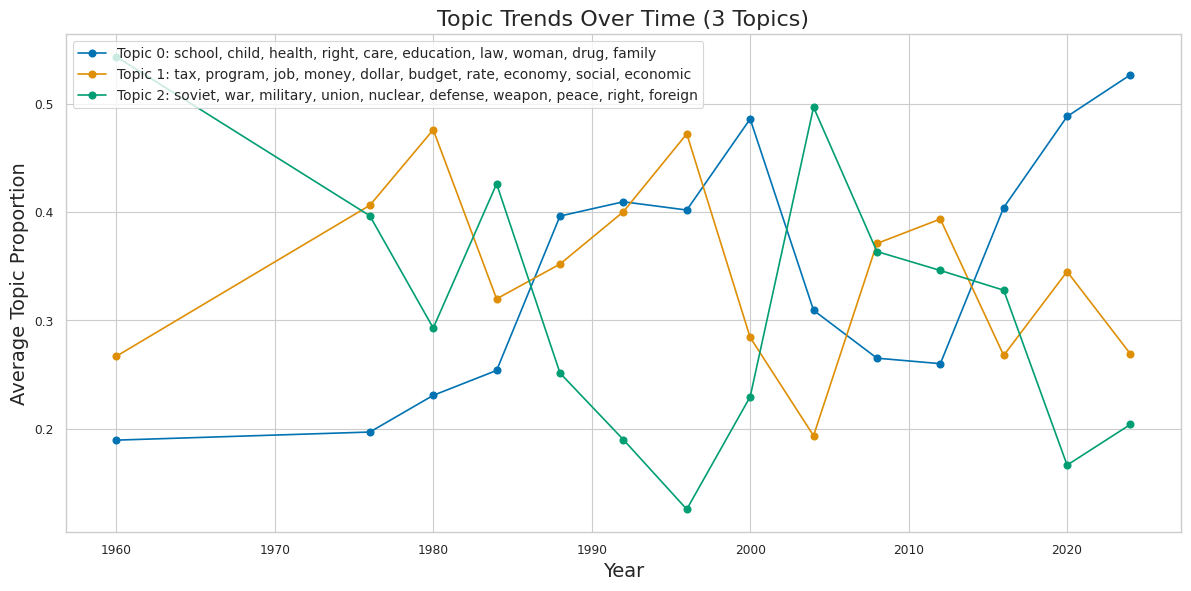

In [149]:
plot_topic_trends_over_time(ldaseq_3_topics, title="Topic Trends Over Time (3 Topics)")

### Train the LDASeqModel with 4 Topics

In [ ]:
ldaseq_4_topics = LdaSeqModel(
    corpus=corpus,
    time_slice=timeslices,
    id2word=dictionary,
    num_topics=4,
    initialize='gensim',
    random_state=42
)

/opt/conda/lib/python3.12/site-packages/gensim/models/ldaseqmodel.py:1480: RuntimeWarning: invalid value encountered in scalar divide
  converged = np.fabs((lhood_old - lhood) / (lhood_old * total))
/opt/conda/lib/python3.12/site-packages/gensim/models/ldaseqmodel.py:298: RuntimeWarning: divide by zero encountered in scalar divide
  convergence = np.fabs((bound - old_bound) / old_bound)
/opt/conda/lib/python3.12/site-packages/gensim/models/ldaseqmodel.py:1480: RuntimeWarning: invalid value encountered in scalar divide
  converged = np.fabs((lhood_old - lhood) / (lhood_old * total))
/opt/conda/lib/python3.12/site-packages/gensim/models/ldaseqmodel.py:1480: RuntimeWarning: invalid value encountered in scalar divide
  converged = np.fabs((lhood_old - lhood) / (lhood_old * total))
/opt/conda/lib/python3.12/site-packages/gensim/models/ldaseqmodel.py:1480: RuntimeWarning: invalid value encountered in scalar divide
  converged = np.fabs((lhood_old - lhood) / (lhood_old * total))
/opt/conda/li

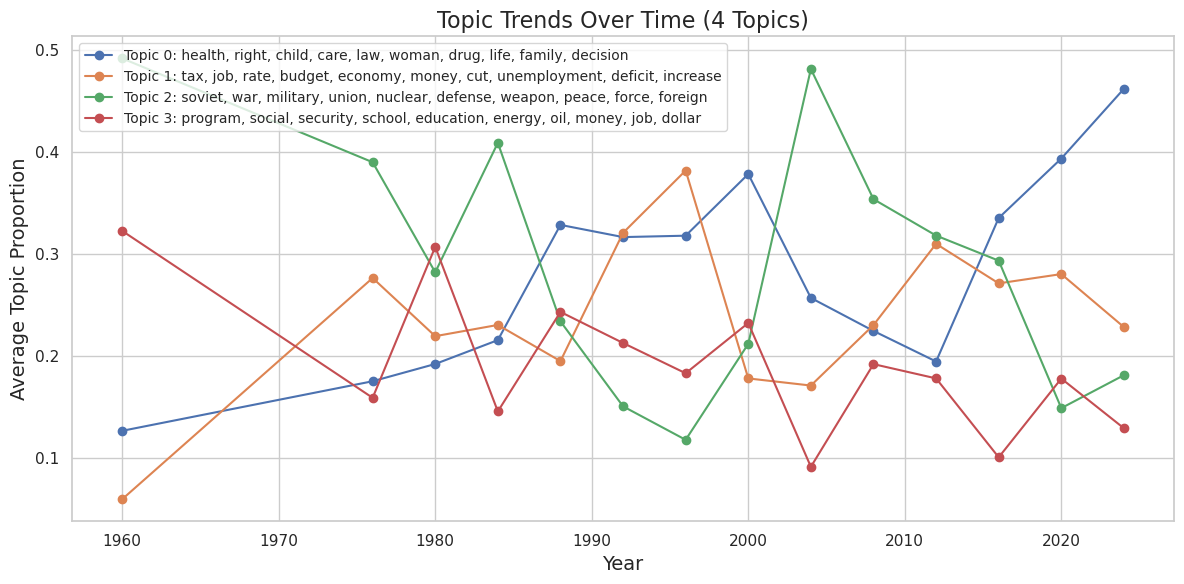

In [ ]:
plot_topic_trends_over_time(ldaseq_4_topics, title="Topic Trends Over Time (3 Topics)")

### Train the LDASeqModel with 5 Topics

In [ ]:
ldaseq_5_topics = LdaSeqModel(
    corpus=corpus,
    time_slice=timeslices,
    id2word=dictionary,
    num_topics=5,
    initialize='gensim',
    random_state=42
)

/opt/conda/lib/python3.12/site-packages/gensim/models/ldaseqmodel.py:1480: RuntimeWarning: invalid value encountered in scalar divide
  converged = np.fabs((lhood_old - lhood) / (lhood_old * total))
/opt/conda/lib/python3.12/site-packages/gensim/models/ldaseqmodel.py:298: RuntimeWarning: divide by zero encountered in scalar divide
  convergence = np.fabs((bound - old_bound) / old_bound)
/opt/conda/lib/python3.12/site-packages/gensim/models/ldaseqmodel.py:1480: RuntimeWarning: invalid value encountered in scalar divide
  converged = np.fabs((lhood_old - lhood) / (lhood_old * total))
/opt/conda/lib/python3.12/site-packages/gensim/models/ldaseqmodel.py:1480: RuntimeWarning: invalid value encountered in scalar divide
  converged = np.fabs((lhood_old - lhood) / (lhood_old * total))
/opt/conda/lib/python3.12/site-packages/gensim/models/ldaseqmodel.py:1480: RuntimeWarning: invalid value encountered in scalar divide
  converged = np.fabs((lhood_old - lhood) / (lhood_old * total))
/opt/conda/li

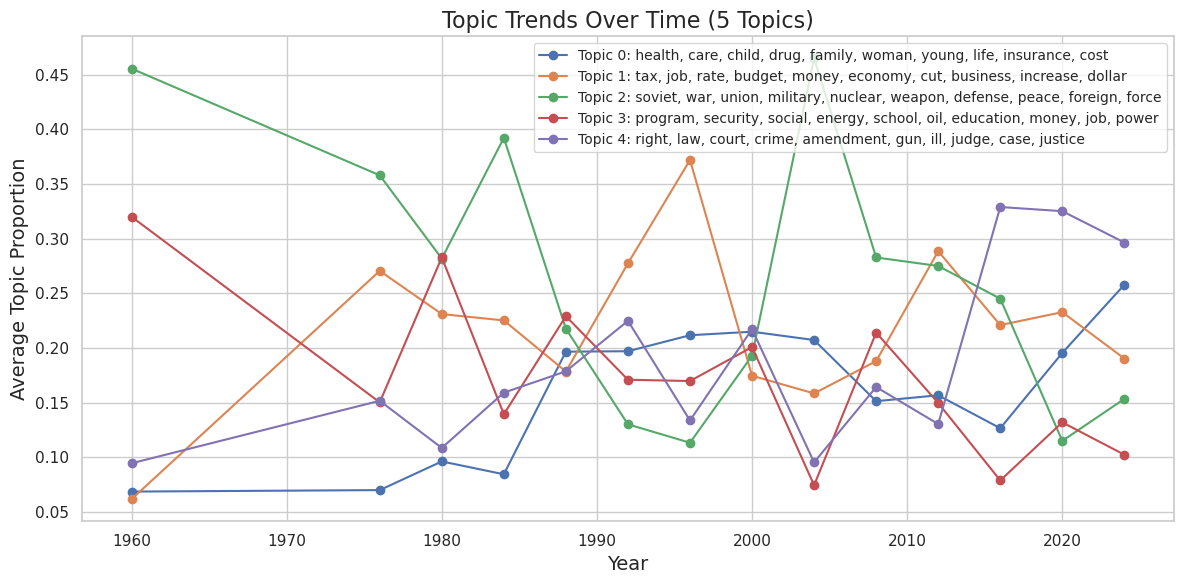

In [ ]:
plot_topic_trends_over_time(ldaseq_5_topics, title="Topic Trends Over Time (3 Topics)")

In [ ]:
topic_id = 2      
top_n = 15        
target_years = [1960, 2004, 2024]  

years = list(grouped.index)

topic2_words_selected_years = {}

for t, year in enumerate(years):
    if year in target_years:
        terms = ldaseq_5_topics.print_topic(topic=topic_id, time=t, top_terms=top_n)
        topic2_words_selected_years[year] = [term for term, _ in terms]

topic2_selected_df = pd.DataFrame.from_dict(topic2_words_selected_years, orient='index').transpose()
topic2_selected_df.index.name = "Top Term Rank"

print(topic2_selected_df)

                    1960         2004       2024
Top Term Rank                                   
0                 soviet          war        war
1                    war      nuclear    nuclear
2                  union         iraq   military
3               military     military       iran
4                nuclear        troop     russia
5                 weapon       weapon       iraq
6                defense        right      troop
7                  peace         iran     weapon
8                foreign        force      right
9                  force     security      force
10              strength         ally       ally
11                 right    terrorist   security
12               freedom  afghanistan  terrorist
13             communist       russia      putin
14              security      foreign     israel


## Topic Modeling using KeyBERT and BERTopic

Although BERTopic is generally robust to raw text and does not require extensive preprocessing, our initial results motivated us to apply light preprocessing and deploy KeyBERT to help the model better focus on relevant topics.

In [152]:
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
docs_cleaned=df_transcripts_candidates["preprocessed_text"].dropna().tolist()

# Fit TF-IDF vectorizer to get top 300 words
tfidf = TfidfVectorizer(max_features=300)
tfidf.fit(docs_cleaned)
top_300_vocab = tfidf.get_feature_names_out()

# Create a new vectorizer restricted to these top 300 words
tfidf_vectorizer= TfidfVectorizer(vocabulary=top_300_vocab)

In [153]:
topic_model = BERTopic(embedding_model=embedding_model, vectorizer_model=tfidf_vectorizer, verbose=True)

In [155]:
topics, probs = topic_model.fit_transform(docs_cleaned)
df_transcripts_candidates['topic'] = topics

topic_model.generate_topic_labels(nr_words=1)

2025-05-28 05:01:23,161 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/140 [00:00<?, ?it/s]

2025-05-28 05:01:28,576 - BERTopic - Embedding - Completed ✓
2025-05-28 05:01:28,578 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-05-28 05:02:01,380 - BERTopic - Dimensionality - Completed ✓
2025-05-28 05:02:01,382 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-05-28 05:02:01,542 - BERTopic - Cluster - Completed ✓
2025-05-28 05:02:01,550 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-05-28 05:02:01,688 - BERTopic - Representation - Completed ✓


['-1_deficit',
 '0_teacher',
 '1_insurance',
 '2_abortion',
 '3_border',
 '4_job',
 '5_social',
 '6_court',
 '7_saddam',
 '8_afghanistan',
 '9_soviet',
 '10_unemployment',
 '11_gun',
 '12_tax',
 '13_bank',
 '14_china',
 '15_russian',
 '16_nuclear',
 '17_tax',
 '18_happy',
 '19_school',
 '20_opinion',
 '21_business',
 '22_terrorist',
 '23_israel',
 '24_civil',
 '25_mission',
 '26_coal',
 '27_water',
 '28_social',
 '29_faith',
 '30_violence',
 '31_east',
 '32_putin',
 '33_police',
 '34_trade',
 '35_right',
 '36_effective',
 '37_russia',
 '38_trade',
 '39_fine',
 '40_law',
 '41_iran',
 '42_border',
 '43_court',
 '44_affordable',
 '45_woman',
 '46_drug',
 '47_economy',
 '48_troop',
 '49_dollar',
 '50_child',
 '51_aid',
 '52_relief',
 '53_pas',
 '54_son',
 '55_oil',
 '56_prescription',
 '57_growth',
 '58_energy',
 '59_cut',
 '60_mistake',
 '61_criminal',
 '62_agency',
 '63_report',
 '64_care',
 '65_korea',
 '66_medicare',
 '67_start',
 '68_bin',
 '69_decision',
 '70_iraq',
 '71_debt',
 '72_

In [156]:
def plot_bertopic_trends(topic_model, df, top_n=10, title="Top Debate Topics Over Time", selected_topics=None, 
    proportions=False,topic_col="topic",year_col="year"):
    """
    Plot the frequency or proportion of topics over time from a BERTopic model.
    - selected_topics: list of topic indexes to plot (if None, use top_n topics)
    - proportions: if True, plot proportions instead of counts
    """
    topic_info = topic_model.get_topic_info()
    if selected_topics is not None:
        top_topics = [t for t in selected_topics if t in topic_info['Topic'].values and t != -1]
    else:
        top_topics = topic_info[topic_info.Topic != -1].head(top_n)['Topic'].tolist()
    years = sorted(df[year_col].unique())
    topic_by_year = []

    for topic in top_topics:
        if proportions:
            proportions_list = []
            for year in years:
                total_docs = len(df[df[year_col] == year])
                topic_docs = len(df[(df[topic_col] == topic) & (df[year_col] == year)])
                proportion = topic_docs / total_docs if total_docs > 0 else 0
                proportions_list.append(proportion)
            topic_by_year.append(proportions_list)
        else:
            counts = [len(df[(df[topic_col] == topic) & (df[year_col] == year)]) for year in years]
            topic_by_year.append(counts)

    
    colors = matplotlib.colormaps['tab20'].colors if len(top_topics) <= 20 else matplotlib.colormaps['hsv'].colors
        
    plt.figure(figsize=(12, 8))
    for i, topic in enumerate(top_topics):
        label = topic_model.topic_labels_[topic]
        plt.plot(
            years, 
            topic_by_year[i], 
            marker='o', 
            linewidth=2,
            color=colors[i % len(colors)], 
            label=label
        )

    plt.xlabel("Year")
    plt.ylabel("Proportion" if proportions else "Mentions")
    plt.title(title)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    for topic in top_topics:
        print(f"\nTopic {topic} ({topic_model.topic_labels_[topic]}):")
        print(topic_model.get_topic(topic))

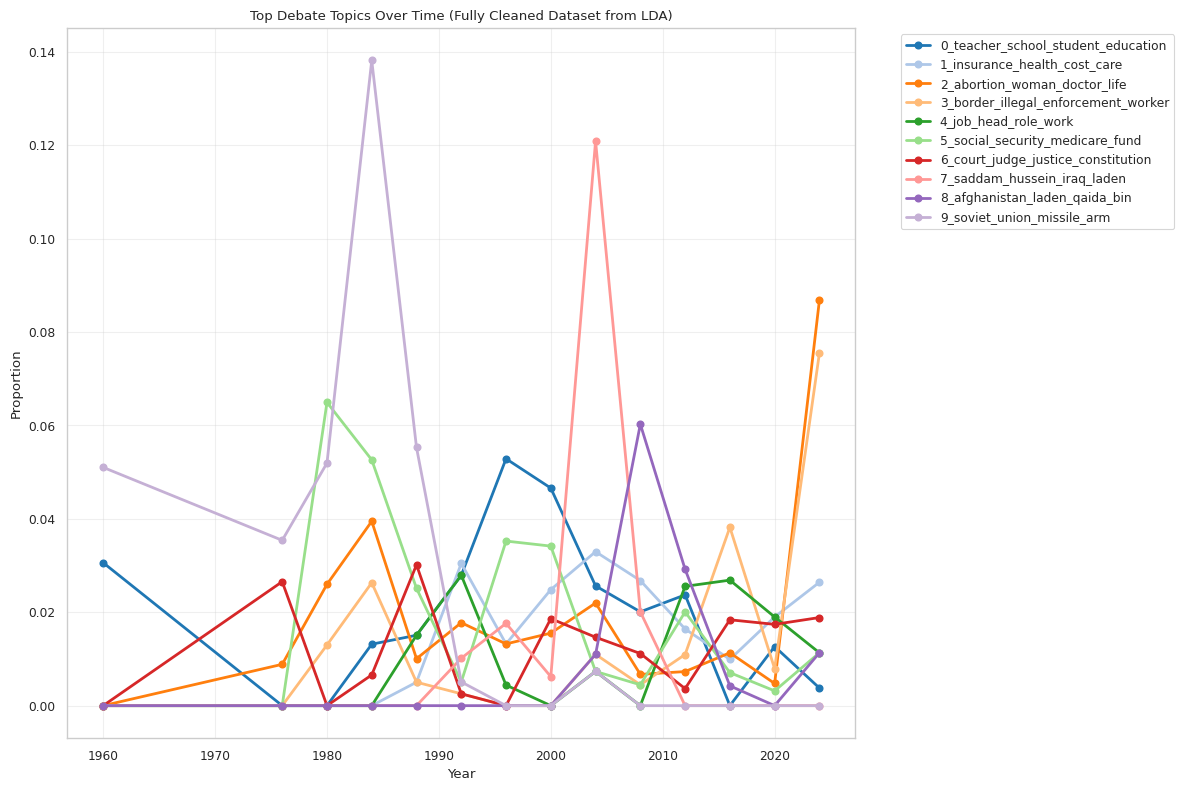


Topic 0 (0_teacher_school_student_education):
[('teacher', 0.13979661994746112), ('school', 0.09534928274148365), ('student', 0.05918258607860671), ('education', 0.05790935940427308), ('local', 0.047203454739550045), ('kid', 0.03714274873360231), ('college', 0.03689873558572448), ('child', 0.03430924570499323), ('loan', 0.024892832586212454), ('parent', 0.024129163403178944)]

Topic 1 (1_insurance_health_cost_care):
[('insurance', 0.15643704760444693), ('health', 0.13580513680385037), ('cost', 0.0649331237784178), ('care', 0.05976612186845371), ('affordable', 0.04771947048421985), ('medical', 0.042297463010053216), ('doctor', 0.027989261742861624), ('incentive', 0.021161273153642624), ('lower', 0.01878364793631496), ('company', 0.018331833468421356)]

Topic 2 (2_abortion_woman_doctor_life):
[('abortion', 0.2562012823068317), ('woman', 0.06044724498293487), ('doctor', 0.04960656731770572), ('life', 0.04370585607590066), ('human', 0.04125067198100865), ('court', 0.03716204100584397), ('

In [159]:
plot_bertopic_trends(
    topic_model, 
    df_transcripts_candidates, 
    top_n=10, 
    title="Top Debate Topics Over Time (Fully Cleaned Dataset from LDA)", 
    proportions=True,
)

### Conduct light Preprocessing

In [160]:
def preprocess(text):
    text = str(text).lower()
    
    text = re.sub(r'[^a-z\s]', '', text)
    
    text = re.sub(r'\s+', ' ', text)
    
    return text.strip()

def get_names_to_remove(df):
    assert 'actor' in df.columns, "DataFrame must contain 'actor' column"
    assert 'first_name' in df.columns, "DataFrame must contain 'first_name' column"
    
    actor_words_to_remove = set(df['actor'].dropna().str.lower().str.strip())
    first_names_to_remove = set(df['first_name'].dropna().str.lower().str.strip())

    names_to_remove = actor_words_to_remove.union(first_names_to_remove)
    names_to_remove.update(["clinton", "bush"])
    return names_to_remove

def remove_political_stopwords(text, names_to_remove):
    assert isinstance(names_to_remove, set), "names_to_remove must be a set"
    assert isinstance(text, str), "text must be a string"
    
    political_stopwords = {
    # Titles
    "president", "senator", "governor", "representative", "congressman", "congresswoman",
    "mayor", "minister", "secretary", "chancellor", "ambassador", "prime", "premier",
    "chairman", "chairwoman", "chief", "officer", "general", "director", "leader", "commander",

    # General political fillers
    "people", "citizens", "citizen", "nation", "country", "government", "state", "party", "administration",
    "public", "leaders", "movement", "society", "officials", "office", "lawmakers","senate", "house", "congress", 
    "legislature", "parliament", "assembly",

    # Time references
    "year", "day", "month", "time", "decade", "century", "years", "minute", "minutes", "hour", "hours", "tonight",
    "today", "tomorrow", "yesterday", "week", "weeks", "decades", "centuries",

    # Geopolitical/administrative
    "state", "states", "district", "region", "city", "capital", "province", "territory", "america", "american",

    # Procedural terms
    "vote", "election", "voter", "campaign", "resolution", "policy", "platform", "debate"}
    
    terms_to_remove = set(political_stopwords).union(names_to_remove)
    
    if pd.isnull(text):
        return ""
    tokens = text.split()
    filtered_tokens = [word for word in tokens if word.lower() not in terms_to_remove]
    filtered_tokens = [word for word in filtered_tokens if len(word) > 2]  # Remove short words
    return " ".join(filtered_tokens)

In [161]:
names_to_remove= get_names_to_remove(df_transcripts_candidates)

df_transcripts_candidates['preprocessed_text_BERTopic'] = df_transcripts_candidates['dialogue'].apply(preprocess)
df_transcripts_candidates['preprocessed_text_BERTopic'] = df_transcripts_candidates['preprocessed_text_BERTopic'].apply(remove_political_stopwords, args=(names_to_remove,))
df_transcripts_candidates = df_transcripts_candidates[df_transcripts_candidates['preprocessed_text_BERTopic'].str.len() > 10]

docs = df_transcripts_candidates['preprocessed_text_BERTopic'].tolist()

### Apply KeyBERT for Keywords Extraction

In [ ]:
kw_model = KeyBERT()
keywords = kw_model.extract_keywords(docs, stop_words="english", top_n=5, use_maxsum=True)

In [ ]:
vocab = list(set([kw for kws in keywords for kw, _ in kws]))

vectorizer_model = CountVectorizer(vocabulary=vocab)

topic_model = BERTopic(embedding_model=embedding_model, vectorizer_model=vectorizer_model)

In [ ]:
topics, probs = topic_model.fit_transform(docs)
df_transcripts_candidates['topic'] = topics

topic_model.generate_topic_labels(nr_words=1)

['-1_said',
 '0_energy',
 '1_thank',
 '2_schools',
 '3_health',
 '4_ill',
 '5_tax',
 '6_trade',
 '7_abortion',
 '8_iran',
 '9_deficit',
 '10_medicare',
 '11_border',
 '12_soviet',
 '13_vice',
 '14_tax',
 '15_saddam',
 '16_afghanistan',
 '17_israel',
 '18_court',
 '19_banks',
 '20_social',
 '21_returns',
 '22_putin',
 '23_guns',
 '24_military',
 '25_defense',
 '26_dollars',
 '27_elaine',
 '28_inaudible',
 '29_terrorists',
 '30_vaccine',
 '31_ballots',
 '32_syria',
 '33_nuclear',
 '34_stamina',
 '35_cities',
 '36_drug',
 '37_shes',
 '38_police',
 '39_thats',
 '40_crosstalk',
 '41_korea',
 '42_milosevic',
 '43_faith',
 '44_quotas',
 '45_russia',
 '46_green',
 '47_applause',
 '48_shut',
 '49_isis',
 '50_slowest',
 '51_women',
 '52_oil',
 '53_parsing',
 '54_law',
 '55_cases',
 '56_kristen',
 '57_cuba',
 '58_businesses',
 '59_pakistan',
 '60_ridiculous',
 '61_georgia',
 '62_foundation',
 '63_calm',
 '64_farmers',
 '65_marriage',
 '66_waiting',
 '67_veterans',
 '68_strategy',
 '69_true',
 '70

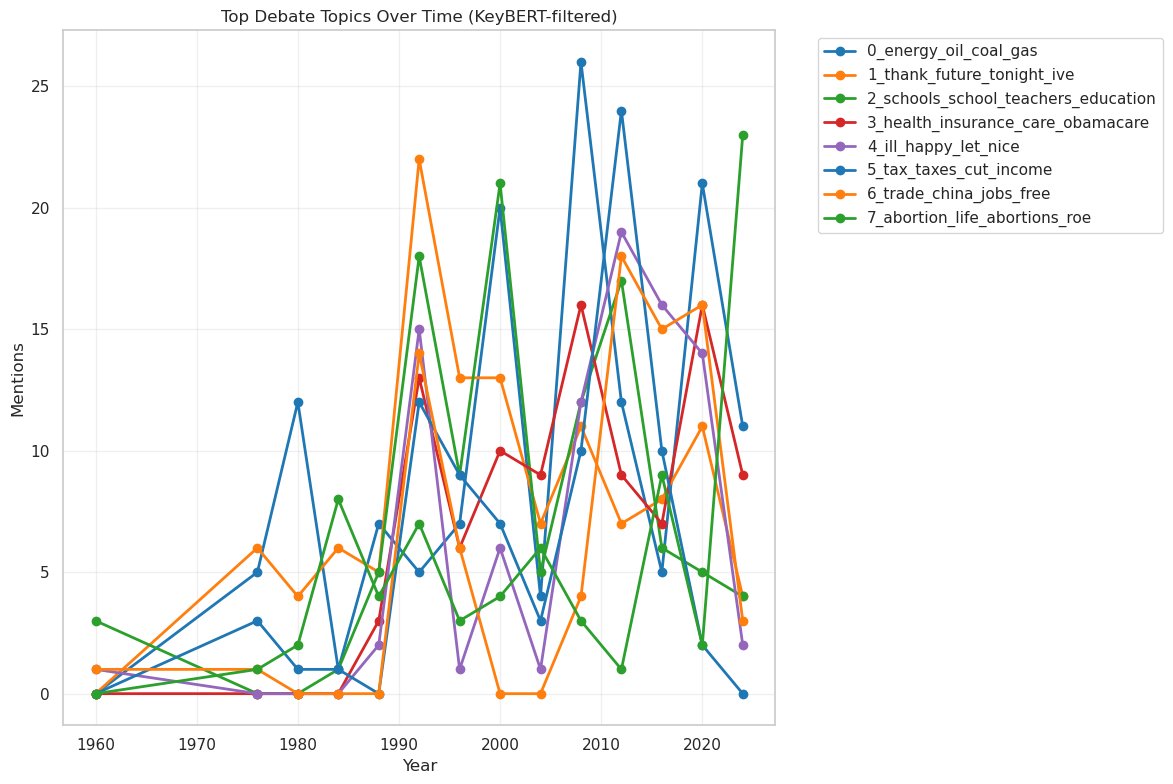


Topic 0 (0_energy_oil_coal_gas):
[('energy', 0.04983163687198573), ('oil', 0.04096893033097736), ('coal', 0.03307198277305546), ('gas', 0.024067284795913087), ('environment', 0.02020349803537552), ('climate', 0.01718314849372407), ('air', 0.015052867010911892), ('drilling', 0.013727964480479263), ('natural', 0.01362388122813951), ('solar', 0.013281102269266914)]

Topic 1 (1_thank_future_tonight_ive):
[('thank', 0.02340395878463825), ('future', 0.017446977810827217), ('tonight', 0.01594385729750142), ('ive', 0.012724122609810278), ('debate', 0.012475134161029975), ('think', 0.01173738459357675), ('im', 0.011528906709146313), ('believe', 0.01147046077786127), ('want', 0.010381657288610568), ('know', 0.010147337898752912)]

Topic 2 (2_schools_school_teachers_education):
[('schools', 0.04928434448991125), ('school', 0.04826325179793858), ('teachers', 0.03805597695541808), ('education', 0.03675628285841094), ('children', 0.024364876463750112), ('parents', 0.02016956639508214), ('kids', 0.0

In [ ]:
plot_bertopic_trends(topic_model, df_transcripts_candidates, top_n=11, title="Top Debate Topics Over Time (KeyBERT-filtered)")

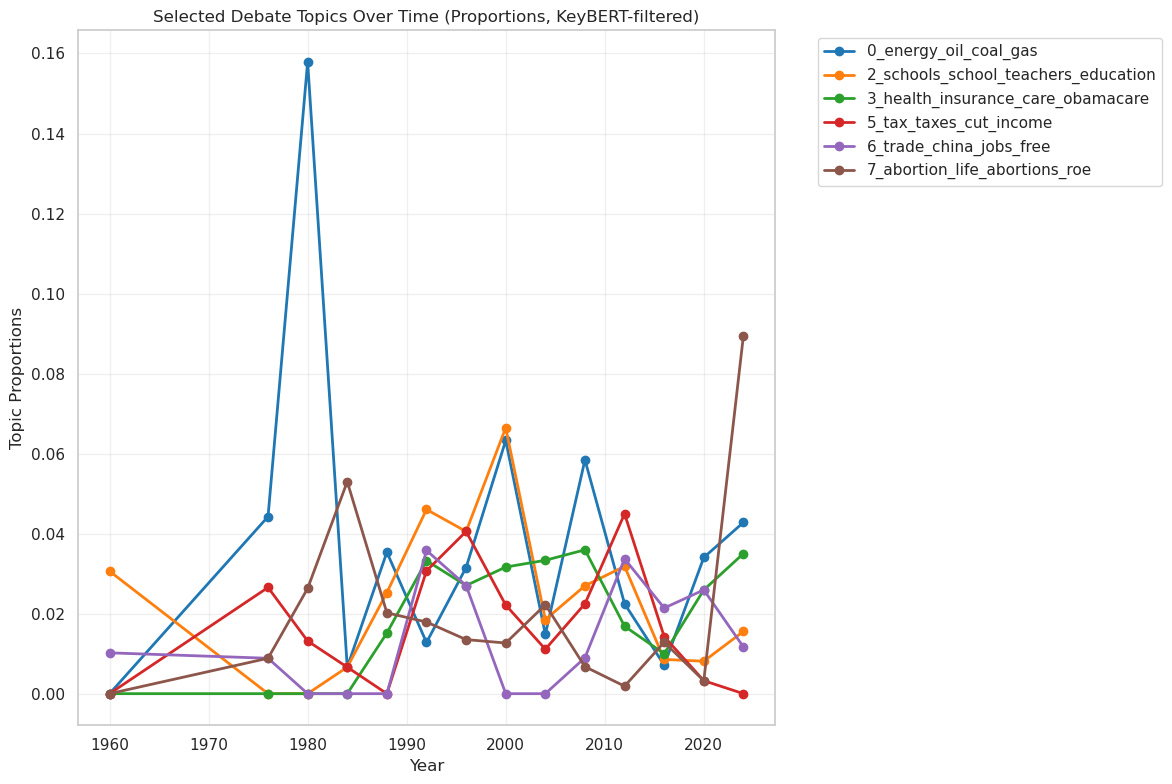


Topic 0 (0_energy_oil_coal_gas):
[('energy', 0.04983163687198573), ('oil', 0.04096893033097736), ('coal', 0.03307198277305546), ('gas', 0.024067284795913087), ('environment', 0.02020349803537552), ('climate', 0.01718314849372407), ('air', 0.015052867010911892), ('drilling', 0.013727964480479263), ('natural', 0.01362388122813951), ('solar', 0.013281102269266914)]

Topic 2 (2_schools_school_teachers_education):
[('schools', 0.04928434448991125), ('school', 0.04826325179793858), ('teachers', 0.03805597695541808), ('education', 0.03675628285841094), ('children', 0.024364876463750112), ('parents', 0.02016956639508214), ('kids', 0.018474668822526946), ('college', 0.017396285204760418), ('local', 0.017227966522231342), ('money', 0.015989015399086565)]

Topic 3 (3_health_insurance_care_obamacare):
[('health', 0.06671555157700013), ('insurance', 0.055548551648745496), ('care', 0.0532793234331394), ('obamacare', 0.024668490553194325), ('costs', 0.023432861721622143), ('plan', 0.0223487169983298

In [ ]:
plot_bertopic_trends(topic_model, df_transcripts_candidates,selected_topics=[0, 2, 3, 5, 6, 7], proportions=True, title="Top Debate Topics Over Time (KeyBERT-filtered)")